# game
## payoff matrix
T,R,P,S = 3,2,1,0

## Preparation

In [1]:
import random
import math

import os
import json
from types import SimpleNamespace
from concurrent.futures import ProcessPoolExecutor
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch

# make sure output folder exists
os.makedirs("logs", exist_ok=True)

# hyperparameters

LAG = 50


## Environment


In [2]:
C, D = 0, 1

PAYOFF = [
    [(2, 2), (0, 3)],
    [(3, 0), (1, 1)]
]

class MatchState:
    def __init__(self, N=5, T=200, e = 0.01):
        self.N = N
        self.T = T
        self.e = e
        self.reset_match()
    
    def set_strategies(self, s1, s2):
        self.strategy1_name = str(s1)
        self.strategy2_name = str(s2)

    def reset_game(self):
        if self.history:
            self.all_history.append({
                "strategy1": self.strategy1_name,
                "strategy2": self.strategy2_name,
                "history": self.history.copy()
            })
        self.history = []
        self.t = 0
        self.n += 1

    def reset_match(self):
        self.history = []
        self.all_history = []
        self.t = 0
        self.n = 0

    @property
    def turn(self):
        return self.t

    def history_for_player(self, player_id):
        if player_id == 1:
            return self.history
        return [(b, a, r2, r1) for (a, b, r1, r2) in self.history]

    def _state_for_player(self, player_id):
        return SimpleNamespace(history=self.history_for_player(player_id), turn=self.turn)

    def step(self, a, b):
        # trembling hand noise (independent per player)
        if random.random() < self.e:
            a = 1 - a  # flip action of player 1

        if random.random() < self.e:
            b = 1 - b  # flip action of player 2

        r1, r2 = PAYOFF[a][b]

        self.history.append((a, b, r1, r2))
        self.t += 1

        return a,b,r1,r2

    def is_game_over(self):
        return self.t >= self.T

    def is_match_over(self):
        return self.n >= self.N
    
    def step_play(self, strategy1, strategy2):
        s1_state = self._state_for_player(1)
        s2_state = self._state_for_player(2)

        a = strategy1.act(s1_state)
        b = strategy2.act(s2_state)

        if a not in (0, 1):
            raise ValueError(f"{strategy1.__class__.__name__} returned invalid move: {a}")
        if b not in (0, 1):
            raise ValueError(f"{strategy2.__class__.__name__} returned invalid move: {b}")

        a, b, r1, r2 = self.step(a, b)

        # increment the strategies' memories
        strategy1.remember(a, b, r1, r2)
        strategy2.remember(b, a, r2, r1)
        return a, b, r1, r2

    def game_play(self, strategy1, strategy2):
        self.reset_game()
        strategy1.reset()
        strategy2.reset()

        while not self.is_game_over():
            self.step_play(strategy1, strategy2)

        return self.history
    
    def match_play(self, strategy1, strategy2):
        self.reset_match()
        self.set_strategies(strategy1, strategy2)

        while not self.is_match_over():
            self.reset_game()
            strategy1.reset()
            strategy2.reset()

            while not self.is_game_over():
                self.step_play(strategy1, strategy2)

        if self.history:
            self.all_history.append({
                "strategy1": self.strategy1_name,
                "strategy2": self.strategy2_name,
                "history": self.history.copy()
            })

        return self.all_history


# Population initiation



In [3]:
class Strategy:
    """
    Base class for IPD strategies.

    Contract:
    - act(state) must return 0 (C) or 1 (D)
    - reset() must clear internal state between matches
    """
    def __str__(self):
        return self.__class__.__name__

    COOP = 0
    DEFECT = 1

    def __init__(self, **kwargs):
        """Allow subclasses to accept additional parameters."""
        pass

    def reset(self):
        """Reset internal state before a new match."""
        pass

    def remember(self, my_action, opp_action, reward1, reward2):
        """Optional: remember the last actions for internal state."""
        pass

    def act(self, state):
        """
        Decide next action.

        Parameters:
            state:
                state.history -> list of (my_action, opp_action)
                state.turn   -> int

        Returns:
            int: 0 (COOP) or 1 (DEFECT)
        """
        raise NotImplementedError

### Finite State Machine

In [4]:
class TitForTat(Strategy):
    def reset(self):
        self.last_opponent = self.COOP

    def remember(self, my_move, opponent_move,r1,r2):
        self.last_opponent = opponent_move

    def act(self, state):
        if not hasattr(self, "last_opponent"):
            self.reset()

        return self.last_opponent


class TitForTwoTats(Strategy):
    def reset(self):
        self.last_two = [self.COOP, self.COOP]

    def remember(self, my_move, opponent_move,r1,r2):
        self.last_two = [self.last_two[-1], opponent_move]

    def act(self, state):
        if not hasattr(self, "last_two"):
            self.reset()

        if self.last_two[0] == self.DEFECT and self.last_two[1] == self.DEFECT:
            return self.DEFECT

        return self.COOP

In [5]:
# state = MatchState(N=5, T=100)
# games = state.match_play(TitForTwoTats(), Pavlov())

# print(games)

### Axelrods Strategies

In [6]:
class K59R(Strategy):
    def reset(self):
        self.tot_cop = 0
        self.tot_def = 0
        self.nice1 = 0
        self.nice2 = 0
        self.prev_move = self.COOP
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        if my_move == self.COOP:
            self.tot_cop += 1
            if opp_move == self.COOP:
                self.nice1 += 1
        else:
            self.tot_def += 1
            if opp_move == self.COOP:
                self.nice2 += 1
        self.prev_move = my_move

    def act(self, state):
        COOP, DEFECT = self.COOP, self.DEFECT

        if self.M == 0:
            return COOP

        good = (self.nice1 / self.tot_cop) if self.tot_cop > 0 else 1.0
        bad  = (self.nice2 / self.tot_def) if self.tot_def > 0 else 0.0

        C   = 6.0 * good - 8.0 * bad - 2.0
        ALT = 4.0 * good - 5.0 * bad - 1.0

        if C >= 0.0 and C >= ALT:
            return COOP
        elif C >= 0.0:
            return 1 - self.prev_move
        elif ALT >= 0.0:
            return 1 - self.prev_move
        else:
            return DEFECT


class K73R(Strategy):
    def reset(self):
        self.IAGGD = 4
        self.IDUNU = 0
        self.IDUNB = 0
        self.IPAYB = 8
        self.ITEST = 1
        self.IPOST = 0
        self.K = 0
        self.M = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.K += r_self
        self.M += 1
        self.last_opp = opp_move

    def act(self, state):
        COOP, DEFECT = self.COOP, self.DEFECT

        if self.M == 0:
            return self.IPOST

        J = self.last_opp
        move = self.IPOST

        if J != self.ITEST:
            return move

        if self.ITEST == 1:
            self.IDUNU += 1
        else:
            self.IDUNB += 1

        if (self.IDUNU < self.IAGGD) and (self.IDUNB < self.IPAYB):
            return move

        self.IDUNU = 0
        self.IDUNB = 0

        self.IPOST = 1 if J == 1 else 0
        move = self.IPOST

        self.ITEST = 0 if self.IPOST == 1 else 1

        if self.ITEST == 1:
            self.IAGGD = max(1, self.IAGGD - 3 + (self.K // max(1, self.M)))
        else:
            self.IPAYB = int(1.6667 * (self.IAGGD + 1))

        return move


class K74R(Strategy):
    def reset(self):
        self.ALPHA = 1.0
        self.BETA = 0.3
        self.IOLD = 0
        self.QCA = 0.0
        self.QNA = 0.0
        self.QCB = 0.0
        self.QNB = 0.0
        self.K74R_val = 0
        self.JSW = 0
        self.JS4 = 0
        self.JS11 = 0
        self.JR = 0
        self.JL = 0
        self.JT = 0
        self.JSM = 1
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        J = opp_move

        if self.M > 2:
            if self.IOLD == self.COOP:
                if J == self.COOP:
                    self.QCA += 1
                self.QNA += 1
                self.ALPHA = self.QCA / self.QNA if self.QNA > 0 else 1.0
                self.QCA *= 0.8
                self.QNA *= 0.8
            else:
                if J == self.COOP:
                    self.QCB += 1
                self.QNB += 1
                self.BETA = self.QCB / self.QNB if self.QNB > 0 else 0.0
                self.QCB *= 0.8
                self.QNB *= 0.8

        if self.M <= 37:
            if J == self.JL:
                self.JSM += 1
                if self.JSM >= 3:
                    self.JS4 = 1
                if self.JSM >= 11:
                    self.JS11 = 1
            else:
                self.JSW += 1
                self.JSM = 1
            self.JT += J

        self.JL = J

        if self.M == 37:
            if (self.JS4 == 1 and
                self.JS11 == 0 and
                10 < self.JT < 26 and
                self.JSW < 26):
                self.JR = 1

    def act(self, state):
        COOP, DEFECT = self.COOP, self.DEFECT

        if self.M == 0:
            return COOP

        if self.JR == 1:
            return DEFECT

        self.IOLD = self.K74R_val

        POLC = 6 * self.ALPHA - 8 * self.BETA - 2
        POLALT = 4 * self.ALPHA - 5 * self.BETA - 1

        if POLC == 0 and POLC >= POLALT:
            self.K74R_val = COOP
            return COOP

        if POLALT >= 0:
            self.K74R_val = 1 - self.K74R_val
            return self.K74R_val

        self.K74R_val = DEFECT
        return DEFECT


class K74RXX(Strategy):
    def reset(self):
        self.ALPHA = 1.0
        self.BETA = 0.3
        self.IOLD = 0
        self.QCA = 0.0
        self.QNA = 0.0
        self.QCB = 0.0
        self.QNB = 0.0
        self.k74dummy = 0
        self.JSW = 0
        self.JS4 = 0
        self.JS11 = 0
        self.JR = 0
        self.JL = 0
        self.JT = 0
        self.JSM = 1
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        J = opp_move

        if self.M > 2:
            if self.IOLD == self.COOP:
                if J == self.COOP:
                    self.QCA += 1
                self.QNA += 1
                self.ALPHA = self.QCA / self.QNA if self.QNA > 0 else 1.0
                self.QCA *= 0.8
                self.QNA *= 0.8
            else:
                if J == self.COOP:
                    self.QCB += 1
                self.QNB += 1
                self.BETA = self.QCB / self.QNB if self.QNB > 0 else 0.0
                self.QCB *= 0.8
                self.QNB *= 0.8

        if self.M <= 37:
            if J == self.JL:
                self.JSM += 1
                if self.JSM >= 3:
                    self.JS4 = 1
                if self.JSM >= 11:
                    self.JS11 = 1
            else:
                self.JSW += 1
                self.JSM = 1
            self.JT += J

        self.JL = J

        if self.M == 37:
            if (self.JS4 == 1 and
                self.JS11 == 0 and
                10 < self.JT < 26 and
                self.JSW < 26):
                self.JR = 1

    def act(self, state):
        COOP, DEFECT = self.COOP, self.DEFECT

        if self.M == 0:
            return COOP

        if self.JR == 1:
            self.k74dummy = DEFECT
            return DEFECT

        self.IOLD = self.k74dummy

        POLC = 6 * self.ALPHA - 8 * self.BETA - 2
        POLALT = 4 * self.ALPHA - 5 * self.BETA - 1

        if POLC == 0 and POLC >= POLALT:
            self.k74dummy = COOP
            return COOP

        if POLALT >= 0:
            self.k74dummy = 1 - self.k74dummy
            return self.k74dummy

        self.k74dummy = DEFECT
        return DEFECT


class K75R(Strategy):
    def reset(self):
        self.HIST = [[0, 0] for _ in range(4)]
        self.IBURN = 0
        self.ID = [0, 0]
        self.IDEF = 0
        self.ITWIN = 0
        self.ISTRNG = 0
        self.ICOOP = 0
        self.ITRY = 0
        self.IRDCHK = 0
        self.IRAND = 0
        self.IPARTY = 1
        self.IND = 0
        self.MY = 0
        self.INDEF = 5
        self.IOPP = 0
        self.PROB = 0.2
        self.last_J = 0
        self.last_r = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_J = opp_move
        self.last_r = r_self
        self.M += 1

    def act(self, state):
        COOP, DEFECT = self.COOP, self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_J

        if self.IRAND == 1:
            self.IRDCHK += J * 4 - 3
            if self.IRDCHK < 11:
                self.MY = DEFECT
                return DEFECT
            else:
                self.IRAND = 2
                self.ICOOP = 2
                self.MY = COOP
                return COOP

        self.IOPP += J
        self.HIST[self.IND][J] += 1

        if (self.M >= 15 and self.M % 15 == 0 and self.IRAND != 2):
            if self.HIST[0][0] / max(1, (self.M - 2)) < 0.8:
                if (self.IOPP * 4 >= (self.M - 2)) and (self.IOPP * 4 <= 3 * self.M - 6):

                    ROW = [sum(row) for row in self.HIST]
                    COL = [sum(self.HIST[i][j] for i in range(4)) for j in range(2)]

                    chi = 0.0
                    for i in range(4):
                        for j2 in range(2):
                            expected = ROW[i] * COL[j2] / max(1, (self.M - 2))
                            if expected > 1:
                                diff = self.HIST[i][j2] - expected
                                chi += (diff ** 2) / expected

                    if chi <= 3:
                        self.IRAND = 1
                        self.MY = DEFECT
                        return DEFECT

        if self.ITRY == 1 and J == DEFECT:
            self.IBURN = 1

        if self.M <= 37 and J == COOP:
            self.ITWIN += 1

        if self.M == 38 and J == DEFECT:
            self.ITWIN += 1

        if self.M >= 39 and self.ITWIN == 37 and J == DEFECT:
            self.ITWIN = 0

        if self.ITWIN == 37:
            return self._coop_phase()

        self.IDEF = self.IDEF * J + J
        if self.IDEF >= 20:
            return self._defect_phase()

        self.IPARTY = 3 - self.IPARTY
        idx = self.IPARTY - 1

        self.ID[idx] = self.ID[idx] * J + J
        if self.ID[idx] >= self.INDEF:
            self.ID[idx] = 0
            self.ISTRNG += 1
            if self.ISTRNG == 8:
                self.INDEF = 3

        if self.ICOOP >= 1:
            return self._coop_phase()

        if self.M >= 37 and self.IBURN == 0:
            if self.M == 37 or (self.last_r <= self.PROB):
                self.ITRY = 2
                self.ICOOP = 2
                self.PROB += 0.05
                return self._defect_phase()

        if J == COOP:
            return self._coop_phase()

        return self._defect_phase()

    def _coop_phase(self):
        self.ITRY -= 1
        self.ICOOP -= 1
        self.MY = self.COOP
        self._update_index()
        return self.COOP

    def _defect_phase(self):
        idx = self.IPARTY - 1
        self.ID[idx] += 1
        self.MY = self.DEFECT
        self._update_index()
        return self.DEFECT

    def _update_index(self):
        self.IND = 2 * self.MY + self.last_J

In [7]:
import random

class K92R(Strategy):
    def reset(self):
        self.last_opp = self.COOP
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        if self.M == 0:
            return self.COOP
        return self.last_opp


class KPavlovC(Strategy):
    def reset(self):
        self.last_my = self.COOP
        self.last_opp = self.COOP
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_my = my_move
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        if self.M == 0:
            return self.COOP

        if self.last_opp == self.last_my:
            return self.COOP
        else:
            return self.DEFECT


class KRandomC(Strategy):
    def reset(self):
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1

    def act(self, state):
        return self.DEFECT if random.random() <= 0.5 else self.COOP


class KTF2TC(Strategy):
    def reset(self):
        self.last_opp = self.COOP
        self.prev_opp = self.COOP
        self.count = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.prev_opp = self.last_opp
        self.last_opp = opp_move
        self.count += 1

    def act(self, state):
        if self.count == 0:
            return self.COOP

        if self.count < 2:
            return self.COOP

        if self.last_opp == self.DEFECT and self.prev_opp == self.DEFECT:
            return self.DEFECT

        return self.COOP


class KTitForTatC(Strategy):
    def reset(self):
        self.last_opp = self.COOP
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        if self.M == 0:
            return self.COOP
        return self.last_opp

In [8]:
import random
import math

class GRASR(Strategy):
    def reset(self):
        self.NMOV = [0, 0, 0, 0]
        self.NMOVE = 0
        self.IGAME = 0
        self.N = 0
        self.MMOVE = 0
        self.last_opp = 0
        self.JSCOR = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.JSCOR += r_opp
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            self.reset()
            return COOP

        M = self.M + 1
        JPICK = self.last_opp
        JSCOR = self.JSCOR
        RANDO = random.random()

        if M <= 2:
            return COOP

        if M < 51:
            return JPICK

        if M == 51:
            return DEFECT

        if M < 57:
            idx = M - 53
            if 0 <= idx < 4:
                self.NMOV[idx] = self.MMOVE + JPICK

            move = JPICK

            if move == COOP:
                self.MMOVE = 2
            else:
                self.MMOVE = 4

            return move

        if M == 57:
            if JSCOR > 135:
                J = self.NMOV[1]

                if J == 1:
                    if self.NMOV[0] == 3 and self.NMOV[2] >= 3:
                        self.IGAME = 2
                        return COOP

                elif J == 2:
                    if self.NMOV[0] == 2 and self.NMOV[2] >= 4 and self.NMOV[3] >= 2:
                        self.IGAME = 4
                        return COOP

                elif J == 3:
                    if self.NMOV[0] == 5 and self.NMOV[2] >= 5:
                        self.IGAME = 2
                        return COOP

                self.IGAME = 1
                self.N = int(RANDO * 10 + 5)
                return COOP
            else:
                self.IGAME = 3
                return DEFECT

        if self.IGAME == 1:
            if self.N <= 0:
                self.N = int(RANDO * 10 + 5)
                return DEFECT
            else:
                self.N -= 1
                return JPICK

        elif self.IGAME == 2:
            return JPICK

        elif self.IGAME == 3:
            return DEFECT

        elif self.IGAME == 4:
            if M >= 118:
                self.IGAME = 2
            return COOP

        return COOP


class K31R(Strategy):
    def reset(self):
        self.S = 0.0
        self.M = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.S += opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return DEFECT

        M = self.M + 1
        A = self.S / M if M > 0 else 0

        if A < 0.5:
            return COOP
        return DEFECT


class K32R(Strategy):
    def reset(self):
        self.C1 = 0
        self.C2 = 0
        self.C3 = 0
        self.C4 = 0

        self.J2 = 0
        self.J1 = 0
        self.I2 = 0
        self.I1 = 0

        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if self.M > 2:
            if self.I2 == self.DEFECT:
                if opp_move == self.COOP:
                    self.C1 += 1
                else:
                    self.C2 += 1
            else:
                if opp_move == self.COOP:
                    self.C3 += 1
                else:
                    self.C4 += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        R = random.random()
        M = self.M + 1

        if M >= 27:
            if (self.C1 >= ((self.C1 + self.C2) - 1.5 * math.sqrt(self.C1 + self.C2)) / 2 and
                self.C4 >= ((self.C3 + self.C4) - 1.5 * math.sqrt(self.C3 + self.C4)) / 2):
                move = DEFECT
                self._update_memory(J, move)
                return move

        move = COOP

        if self.J1 == J:
            if self.J2 == self.J1:
                move = J
            else:
                P = 0.9
                move = J if R < P else 1 - J
        else:
            if J == DEFECT:
                P = 0.6
            else:
                P = 0.7
            move = J if R < P else 1 - J

        self._update_memory(J, move)
        return move

    def _update_memory(self, J, move):
        self.J2 = self.J1
        self.J1 = J
        self.I2 = self.I1
        self.I1 = move

In [9]:
import random

class K33R(Strategy):
    def reset(self):
        self.coop_count = [0.0] * 4
        self.count = [0.0] * 4
        self.P = [0.0] * 4

        self.LAST1 = 1
        self.LAST2 = 1

        self.TWIN = True
        self.M = 0
        self.last_opp = 0

        self.CONST = [0., 4., 6., 6., 8., 12.]
        self.COEFF = [
            [36., 16., 0., 12.],
            [0., 12., 18., 12.],
            [0., 12., 24., 9.],
            [0., 0., 0., 9.],
            [12., 48., 0., 0.],
            [0., 0., 0., 0.]
        ]

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move

        if self.M > 2:
            INDEX = 2 * self.LAST2 + self.LAST1
            self.coop_count[INDEX] += (1 - opp_move)
            self.count[INDEX] += 1
            if self.count[INDEX] > 0:
                self.P[INDEX] = self.coop_count[INDEX] / self.count[INDEX]

        if self.M > 1 and opp_move != self.LAST1:
            self.TWIN = False

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        M = self.M + 1
        INDEX = 2 * self.LAST2 + self.LAST1

        if M <= 22:
            move = COOP if INDEX in [0, 1] else DEFECT
            self._update(move)
            return int(move)

        if self.TWIN:
            move = COOP
            self._update(move)
            return int(move)

        BEST = -float("inf")
        IPOL = 0

        for i in range(6):
            SUM = self.CONST[i]
            for j in range(4):
                SUM += self.COEFF[i][j] * self.P[j]
            if SUM > BEST:
                BEST = SUM
                IPOL = i

        policy_map = {
            0: [COOP, COOP, COOP, COOP],
            1: [DEFECT, COOP, COOP, COOP],
            2: [DEFECT, COOP, DEFECT, COOP],
            3: [DEFECT, DEFECT, COOP, COOP],
            4: [DEFECT, DEFECT, DEFECT, COOP],
            5: [DEFECT, DEFECT, DEFECT, DEFECT],
        }

        policy = policy_map.get(IPOL, [COOP] * 4)
        move = int(policy[INDEX])

        self._update(move)
        return move

    def _update(self, move):
        self.LAST2 = self.LAST1
        self.LAST1 = move

#Grim Trigger
class K34R(Strategy):
    def reset(self):
        self.JT = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.JT += opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if not self.JT:
            return COOP

        if self.JT > 0:
            return DEFECT
        return COOP


class K35R(Strategy):
    def reset(self):
        self.FLACK = 0.0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.FLACK = (self.FLACK + opp_move) * 0.5

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if not self.FLACK:
            return COOP

        R = random.random()

        if self.FLACK > R:
            return DEFECT
        return COOP


class K36R(Strategy):
    def reset(self):
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if not self.M:
            self.reset()

        M = self.M + 1
        R = random.random()

        move = DEFECT

        # change from 1,100,200,300 to 1,100,150,200 to make it align to the tournament
        if 1 <= M < 100:
            PROBC = 0.1
        elif 100 <= M < 150:
            PROBC = 0.05
        elif 150 <= M < 200:
            PROBC = 0.15
        else:
            PROBC = 0.0

        if R < PROBC:
            move = COOP

        return move

In [10]:
import random

# Cooperate unless opponent defects too often (>20%), then defect
class K37R(Strategy):
    def reset(self):
        self.ND = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.ND += opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if not self.ND:
            return COOP

        M = self.M + 1

        if 5 * self.ND > M:
            return DEFECT
        return COOP

# Punish only if opponent defects 3 times in a row, but completely forgive if they return to cooperation.
class K38R(Strategy):
    def reset(self):
        self.MOVE = 0
        self.JHIS = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        if self.MOVE != self.DEFECT:
            if self.JHIS >= 4:
                self.JHIS -= 4
            self.JHIS = self.JHIS * 2 + opp_move

            if self.JHIS == 7:
                self.MOVE = self.DEFECT

    def act(self, state):
        COOP = self.COOP

        if not self.JHIS:
            self.reset()
            return COOP

        return self.MOVE


class K39R(Strategy):
    def reset(self):
        self.STEP = 1
        self.SUBSTP = 1
        self.BOTHD = 0
        self.TITCNT = 0
        self.TATCNT = 0
        self.EVIL = 0
        self.N = 1
        self.F = 0
        self.OK = [0, 0, 0]
        self.TOTK = 0
        self.OLDMOV = 0
        self.VOLDMV = 0   # ✅ FIX
        self.COUNT = 0

        self.last_move = self.COOP
        self.last_opp = None   # ✅ FIX (None = no history)
        self.K = 0
        self.M = 0             # ✅ FIX (turn counter)

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.K += r_self
        self.last_opp = opp_move

        if self.last_move + opp_move == 2:
            self.BOTHD += 1
        else:
            self.BOTHD = 0

        self.COUNT -= 1

        if opp_move == self.DEFECT:
            self.TATCNT += 1
        if self.EVIL == 0 and opp_move == self.DEFECT:
            self.EVIL = 1

        self.VOLDMV = self.OLDMOV
        self.OLDMOV = opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        K = self.K

        move = COOP

        while True:
            if self.STEP == 1:
                if self.SUBSTP == 1:
                    self.COUNT = 10
                    self.TATCNT = 0
                    self.TITCNT = 0
                    self.SUBSTP = 2
                    continue

                elif self.SUBSTP == 2:
                    if (self.VOLDMV + self.OLDMOV) == 2:
                        move = DEFECT
                    else:
                        move = COOP

                    self.TITCNT += move

                    if self.COUNT == 0:
                        self.SUBSTP = 3
                    break

                elif self.SUBSTP == 3:
                    OLDSTP = self.STEP
                    self.OK[self.STEP - 1] = K - self.TOTK
                    self.TOTK = K
                    self.SUBSTP = 1

                    if self.TATCNT == 0:
                        self.STEP = 4
                        if self.EVIL == 1:
                            self.STEP = 1
                        if self.EVIL == 0:
                            self.EVIL = -1
                        continue

                    self.STEP = 1
                    for i1 in range(2):
                        for i2 in range(1, 3):
                            if self.OK[i1] == 0 or self.OK[i2] == 0:
                                continue
                            if self.OK[i1] < self.OK[i2]:
                                if self.STEP == i1 + 1:
                                    self.STEP = i2 + 1

                    if self.STEP != 3:
                        if (self.OK[min(self.STEP, 2)] == 0 and
                            (self.TATCNT >= 4 or self.TITCNT == 0)):
                            self.STEP += 1

                    if self.STEP < OLDSTP and self.BOTHD > 0:
                        self.STEP = 5

                    continue

            elif self.STEP == 2:
                if self.SUBSTP == 1:
                    self.COUNT = 10
                    self.SUBSTP = 2
                    continue

                elif self.SUBSTP == 2:
                    move = DEFECT if self.OLDMOV == DEFECT else COOP
                    self.TITCNT += move
                    if self.COUNT == 0:
                        self.SUBSTP = 3
                    break

                elif self.SUBSTP == 3:
                    self.SUBSTP = 1
                    self.STEP = 1
                    continue

            elif self.STEP == 3:
                if self.SUBSTP == 1:
                    self.COUNT = 10
                    self.SUBSTP = 2
                    continue

                elif self.SUBSTP == 2:
                    move = DEFECT
                    self.TITCNT += 1
                    if self.COUNT == 0:
                        self.SUBSTP = 3
                    break

                elif self.SUBSTP == 3:
                    self.SUBSTP = 1
                    self.STEP = 1
                    continue

            elif self.STEP == 4:
                if self.SUBSTP == 1:
                    self.SUBSTP = 2
                    move = DEFECT
                    self.COUNT = self.N
                    self.TATCNT = 0
                    break

                elif self.SUBSTP == 2:
                    if self.COUNT == 0:
                        self.SUBSTP = 3
                    break

                elif self.SUBSTP == 3:
                    if self.TATCNT == 0:
                        self.F = 1
                        self.SUBSTP = 1
                        continue
                    else:
                        if self.F == 1:
                            self.N += 1
                            self.SUBSTP = 1
                            self.STEP = 1
                            continue
                        else:
                            self.SUBSTP = 4
                            if J == DEFECT:
                                self.N += 1
                            self.TATCNT = J
                            break

                elif self.SUBSTP == 4:
                    if self.TATCNT > 4:
                        self.SUBSTP = 1
                        self.STEP = 1
                        continue
                    break

            elif self.STEP == 5:
                if self.SUBSTP != 2:
                    self.COUNT = 5
                    self.SUBSTP = 2

                if self.COUNT != 0:
                    break
                else:
                    self.SUBSTP = 1
                    self.STEP = 1
                    continue

            break

        self.last_move = move
        return move


class K40R(Strategy):
    def reset(self):
        self.S = 3
        self.W = 0
        self.Q = 0.8
        self.M = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move

        self.S += 1

        if opp_move == self.DEFECT:
            self.W += 1
            self.Q *= 0.5

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        M = self.M + 1
        J = self.last_opp
        R = random.random()

        if M < 3:
            return COOP

        if J == DEFECT:
            self.W += 1

            cond1 = (self.W > 2 and (self.W % 3 == 0))
            cond2 = ((self.W - 1) % 3 == 0)

            if cond1 or cond2:
                self.S = 1
                self.Q *= 0.5
            else:
                if R < self.Q:
                    self.Q *= 0.5
                    return COOP
                else:
                    self.Q *= 0.5
                    return DEFECT

        if self.S in [1, 2]:
            return DEFECT

        cond1 = (self.W > 2 and (self.W % 3 == 0))
        cond2 = ((self.W - 1) % 3 == 0)

        if cond1 or cond2:
            self.S = 1
            self.Q *= 0.5
            return DEFECT

        return COOP

In [11]:
class K41R(Strategy):
    def reset(self):
        self.LAST = [0] * 12
        self.ICASE = 1
        self.IFORGV = 0
        self.last_opp = self.COOP
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP

        if self.M == 0:
            return COOP

        J = self.last_opp
        M = self.M + 1

        if self.ICASE == 1:
            move = J
            self.ICASE = J + 1

        elif self.ICASE == 2:
            move = J
            self.ICASE = 3
            if J == 1:
                self.ICASE = 1

        elif self.ICASE == 3:
            move = J
            if self.IFORGV < M:
                move = 0
            self.IFORGV += 20 * J
            self.ICASE = 1

        LSUM = self.LAST[0]
        for i in range(1, 12):
            LSUM += self.LAST[i]
            self.LAST[i - 1] = self.LAST[i]

        self.LAST[11] = J

        if LSUM >= 5:
            move = 1

        return move


class K42R(Strategy):
    def reset(self):
        self.MHIST = [[0, 0], [0, 0]]
        self.L3MOV = 0
        self.L3ECH = 0
        self.IDEF = 0
        self.ICOOP = 0
        self.IPICK = 0
        self.I2PCK = 0
        self.J2PCK = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if self.M != 1:
            self.MHIST[self.I2PCK][opp_move] += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        JPICK = self.last_opp
        MOVEN = self.M + 1

        if self.IDEF != 0:
            move = DEFECT
        else:
            if self.IPICK == 1 and JPICK == 1:
                self.L3MOV += 1
                if self.L3MOV >= 3:
                    move = COOP
                    self.L3MOV = 0
                    self.L3ECH = 0
                else:
                    move = JPICK
            else:
                self.L3MOV = 0

                if (
                    self.IPICK != JPICK and
                    JPICK == self.I2PCK and
                    self.IPICK == self.J2PCK
                ):
                    self.L3ECH += 1
                    if self.L3ECH >= 3:
                        self.L3ECH = 0
                        self.L3MOV = 0
                        self.ICOOP = 1
                else:
                    self.L3ECH = 0

                move = JPICK

        if (MOVEN - 2) % 25 == 0 and MOVEN != 2:
            self.IDEF = 0
            JNCOP = self.MHIST[0][0] + self.MHIST[1][0]

            if JNCOP < 8:
                if JNCOP < 3:
                    self.IDEF = 1
            else:
                if 100 * self.MHIST[0][0] / max(JNCOP, 1) < 70:
                    self.IDEF = 1

            self.MHIST = [[0, 0], [0, 0]]

            if self.IDEF != 0:
                self.ICOOP = 0
                self.L3MOV = 0
                self.L3ECH = 0
                move = DEFECT

        if self.ICOOP != 0 and move == DEFECT:
            self.ICOOP = 0
            move = COOP

        self.I2PCK = self.IPICK
        self.J2PCK = JPICK
        self.IPICK = move

        return move


class K43R(Strategy):
    def reset(self):
        self.NCC = 0
        self.NCD = 0
        self.NDC = 0
        self.NDD = 0
        self.KOUNT = 0
        self.MYTWIN = 0
        self.IOLD1 = 0
        self.IOLD2 = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if self.M >= 3:
            if self.IOLD2 == 1:
                self.NDC += (1 - opp_move)
                self.NDD += opp_move
            else:
                self.NCC += (1 - opp_move)
                self.NCD += opp_move

    def act(self, state):
        COOP = self.COOP

        if self.M == 0:
            return 0

        J = self.last_opp
        M = self.M + 1

        self.IOLD2 = self.IOLD1

        if M < 16:
            if J == 0 or self.KOUNT >= 3:
                self.IOLD1 = 0
                return 0
            self.KOUNT += 1
            self.IOLD1 = 1
            return 1

        if M == 17 and J == 1 and self.NCD == 1 and self.NDD == 0:
            self.MYTWIN = 1

        if (self.NCD * 3) >= (self.NCC + self.NCD):
            self.IOLD1 = 1
            return 1

        if M % 4 != 0:
            self.IOLD1 = 0
            return 0

        if self.MYTWIN == 1:
            self.IOLD1 = 0
            return 0

        if self.NDC >= (M // 12) or self.NDD == 0:
            self.IOLD1 = 1
            return 1

        self.IOLD1 = 0
        return 0


class K44R(Strategy):
    def reset(self):
        self.MC = 0
        self.F = 2
        self.AM = 4
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1
        self.MC += opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        M = self.M + 1
        R = random.random()

        if M < 3:
            return COOP

        if self.MC < self.AM:
            return COOP

        if self.MC == self.AM:
            return DEFECT

        self.AM = self.AM / self.F
        self.MC = 0

        if R < self.AM:
            return COOP

        return DEFECT


class K45R(Strategy):
    def reset(self):
        self.JOLD = 0
        self.A = 0
        self.B = 0
        self.C = 0
        self.D = 0
        self.E = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return DEFECT

        J = self.last_opp
        M = self.M + 1

        if M <= 3:
            if M == 2:
                self.D = 1 if J == 1 else 0
                return COOP

            if M == 3:
                if J == 1:
                    if self.D == 1:
                        self.C = 1
                    return COOP
                else:
                    if self.D == 1:
                        return COOP
                    self.A = 1
                    return COOP

        if self.C == 1:
            return J

        if self.B == 1:
            move = COOP
            if self.JOLD == 1 and J == 1:
                move = DEFECT
            self.JOLD = J
            return move

        if self.A == 1:
            move = DEFECT
            self.E += 1
            if self.E == 8:
                self.E = 0
                self.JOLD = J
                return move
            if not (self.JOLD == 1 and J == 1):
                move = COOP
            self.JOLD = J
            return move

        if self.D == 1:
            if J == 1:
                self.C = 1
                return DEFECT
            else:
                self.B = 1
                return COOP

        if J == 1:
            self.C = 1
            return COOP
        else:
            self.B = 1
            return COOP

In [12]:
import random

class K46R(Strategy):
    def reset(self):
        self.NJ = 0
        self.last_opp = None
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1
        self.NJ += opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        R = random.random()

        if J == COOP:
            return COOP

        P = self.NJ / self.M if self.M > 0 else 0.0

        return DEFECT if R < P else COOP


class K47R(Strategy):
    def reset(self):
        self.NUM = 2
        self.DEN = 2
        self.RF = 20
        self.LONG = 1
        self.SHORT = 5
        self.SH2 = [1] * 5
        self.N = 1
        self.MYLAST = 0
        self.MYMOVE = 0
        self.last_opp = None
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        J = opp_move

        if self.M <= self.RF and J == self.DEFECT:
            self.RF = self.M + (20 * self.NUM) // self.DEN + 1

        self.N = (self.N % 4) + 1
        self.SHORT -= self.SH2[self.N - 1]

        if J == self.MYLAST:
            self.LONG += 1
            self.SHORT += 1
            self.SH2[self.N - 1] = 1
        else:
            self.SH2[self.N - 1] = 0

        self.MYLAST = self.MYMOVE

        if self.M >= self.RF + 2:
            self.NUM += J
            self.DEN += (1 - J)
            if self.DEN != 0:
                self.RF = self.M + (20 * self.NUM) // self.DEN + 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        M = self.M + 1

        move = J

        if (self.LONG < 0.625 * M) or (self.SHORT < 3):
            move = DEFECT

        if (self.LONG > 0.9 * M) and (self.SHORT == 5):
            move = COOP

        if M == self.RF:
            move = DEFECT

        if M >= self.RF + 2:
            move = COOP

        self.MYMOVE = move
        return move


class K48R(Strategy):
    def reset(self):
        self.IARRAY = [0] * 5
        self.IPO2 = [2, 4, 3, 5, 1]
        self.K5 = 0
        self.KLAST = 0
        self.MM = 0
        self.ICHAN = 1
        self.IPO1 = 1
        self.last_opp = None
        self.M = 0
        self.score = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1
        self.score += r_self

    def act(self, state):
        if self.M == 0:
            return self.COOP

        J = self.last_opp
        M = self.M + 1
        K = self.score

        if M <= 5:
            idx = self.IPO2[self.IPO1 - 1] - 1
            self.IARRAY[idx] = 1 if J == self.DEFECT else 0
            self.IPO1 += J
            return J

        self.MM = ((M - 1) % 5) + 1
        move = self.IARRAY[self.MM - 1]

        if self.MM != 1:
            return move

        KOLD = self.K5
        self.K5 = K - self.KLAST
        self.KLAST = K

        if KOLD > self.K5:
            self.ICHAN = -self.ICHAN
            self.IPO1 += self.ICHAN

        self.IPO1 = max(1, min(5, self.IPO1))

        idx = self.IPO2[self.IPO1 - 1] - 1
        self.IARRAY[idx] = max(0, min(1, self.IARRAY[idx] + self.ICHAN))
        self.IPO1 += self.ICHAN

        move = self.IARRAY[self.MM - 1]

        if move >= 1:
            return self.DEFECT
        else:
            return self.COOP


class K49R(Strategy):
    def reset(self):
        self.JDSUM = 0
        self.last_opp = None
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1
        if opp_move == self.DEFECT:
            self.JDSUM += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        M = self.M + 1
        R = random.random()

        JDPC = (100 * self.JDSUM) // self.M

        if J == COOP:
            move = COOP
        elif self.JDSUM <= 17:
            move = int(R + 0.5)
        else:
            move = DEFECT

        if (M > 19 and JDPC > 79) or \
           (M > 29 and JDPC > 65) or \
           (M > 39 and JDPC > 39):
            move = DEFECT

        return move


class K50R(Strategy):
    def reset(self):
        self.last_opp = None
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        R = random.random()

        if J == COOP:
            return DEFECT if R >= 0.9 else COOP

        return COOP

In [13]:
class K51R(Strategy):
    def reset(self):
        self.LASTI = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            self.reset()
            return COOP

        J = self.last_opp
        M = self.M + 1

        if M <= 8:
            move = COOP
            if M == 6:
                move = DEFECT
            self.LASTI = 0
            return move

        move = COOP
        self.LASTI -= 1

        if self.LASTI == 3:
            move = DEFECT

        if self.LASTI > 0:
            return move

        if J == 1:
            move = DEFECT
            self.LASTI = 4

        return move


class K52R(Strategy):
    def reset(self):
        self.D8 = 0
        self.D9 = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if opp_move <= 0:
            self.D9 = 0
        else:
            self.D9 += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        R = random.random()

        move = COOP

        if self.D9 >= 2:
            move = DEFECT
            if self.D9 >= (5 + 3 * self.D8):
                self.D9 = 0
                self.D8 += 1

        if R <= 0.05:
            move = 1 - move

        return move

# “Estimate opponent’s defect rate over last 10 moves, then respond probabilistically.”
class K53R(Strategy):
    def reset(self):
        self.C = [0] * 10
        self.M = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        if self.M < 10:
            self.C[self.M] = opp_move
        else:
            self.C = self.C[1:] + [opp_move]
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if not hasattr(self, 'last_opp') or self.M == 0:
            return COOP

        R = random.random()

        if self.M <= 10:
            return COOP

        D = sum(1 for x in self.C if x == 1)

        if D > 8:
            return DEFECT if R < 0.94 else COOP
        if D == 8:
            return DEFECT if R < 0.915 else COOP
        if D in [7, 6, 5]:
            return DEFECT if R < 0.87 else COOP
        if D in [4, 3]:
            return DEFECT if R < 0.915 else COOP
        if D == 2:
            return DEFECT if R < 0.87 else COOP
        if D == 1:
            return DEFECT if R < 0.23 else COOP

        return COOP


class K54R(Strategy):
    def reset(self):
        self.OPDEF = 0
        self.STDEF = 0
        self.DL = 0.20
        self.COOPS = 0
        self.OKDEF = True
        self.MYDEF = False
        self.NODEF = 0
        self.ND = 12
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if opp_move == 0:
            self.STDEF = 0
            self.COOPS += 1
        else:
            self.COOPS = 0
            self.STDEF += 1
            self.OPDEF += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        M = self.M + 1

        if M == 20:
            self.DL = 0.10

        if J == 0:
            if float(self.OPDEF) <= float(M) * self.DL and (M % self.ND == 0) and self.OKDEF:
                self.MYDEF = False
                self.NODEF += 1
                if self.NODEF % 6 == 0:
                    self.ND -= 1
                if self.ND < 1:
                    self.ND = 1
                return DEFECT

            self.MYDEF = False
            return COOP

        if M <= 4:
            return DEFECT

        if self.MYDEF:
            self.OKDEF = False

        if float(self.OPDEF) > float(M) * self.DL or self.STDEF > 2:
            if 20 * self.OPDEF <= self.COOPS * M:
                return COOP
            return DEFECT

        self.MYDEF = False
        return COOP


class K55R(Strategy):
    def reset(self):
        self.ALPHA = 1.0
        self.BETA = 0.0
        self.IOLD = 0
        self.QCA = 0
        self.QNA = 0
        self.QCB = 0
        self.QNB = 0
        self.MUTDEF = 0
        self.last_move = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if self.M > 2:
            if self.IOLD == 1:
                if opp_move == 0:
                    self.QCB += 1
                self.QNB += 1
                if self.QNB > 0:
                    self.BETA = self.QCB / self.QNB
            else:
                if opp_move == 0:
                    self.QCA += 1
                self.QNA += 1
                if self.QNA > 0:
                    self.ALPHA = self.QCA / self.QNA

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp

        POLC = 6 * self.ALPHA - 9 * self.BETA - 2
        POLALT = 4 * self.ALPHA - 6 * self.BETA - 1

        if POLC >= 0 and POLC >= POLALT:
            move = COOP

        elif POLC < 0 and POLALT < 0:
            move = DEFECT

            if J == 1 and self.IOLD == 1:
                self.MUTDEF += 1
                if self.MUTDEF > 3:
                    move = COOP
            else:
                self.MUTDEF = 0

        else:
            move = 1 - self.last_move

        self.IOLD = move
        self.last_move = move

        return move

In [14]:
class K56R(Strategy):
    def reset(self):
        self.GOOD = 1.0
        self.BAD = 0.0
        self.PAST = 0
        self.TOTCOP = 0
        self.TOTDEF = 0
        self.NICE1 = 0
        self.NICE2 = 0
        self.last_move = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

        if self.M > 2:
            if self.PAST == self.DEFECT:
                if opp_move == self.COOP:
                    self.NICE2 += 1
                self.TOTDEF += 1
                if self.TOTDEF > 0:
                    self.BAD = self.NICE2 / self.TOTDEF
            else:
                if opp_move == self.COOP:
                    self.NICE1 += 1
                self.TOTCOP += 1
                if self.TOTCOP > 0:
                    self.GOOD = self.NICE1 / self.TOTCOP

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        C = 6.0 * self.GOOD - 8.0 * self.BAD - 2.0
        ALT = 4.0 * self.GOOD - 5.0 * self.BAD - 1.0

        if C >= 0.0 and C >= ALT:
            move = COOP
        elif C >= 0.0 and C < ALT:
            move = 1 - self.last_move
        elif ALT >= 0.0:
            move = 1 - self.last_move
        else:
            move = DEFECT

        self.PAST = move
        self.last_move = move

        return move


class K57R(Strategy):
    def reset(self):
        self.n = 0
        self.last_move = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1
        self.n = 4 * (self.n % 16) + 2 * self.last_move + opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            self.last_move = COOP
            return COOP

        J = self.last_opp
        M = self.M + 1

        if M <= 3:
            move = J
            if M == 3 and self.n == 6:
                move = DEFECT
            self.last_move = move
            return move

        n = self.n
        move = DEFECT

        if n < 39:
            if n <= 0:
                move = COOP
            elif n < 28:
                if n == 27:
                    move = DEFECT
                else:
                    move = COOP
            elif n == 28:
                move = COOP
            elif n < 32:
                move = DEFECT
            else:
                move = COOP

        elif n == 39:
            move = DEFECT

        else:
            if n < 45:
                move = COOP
            elif n == 45:
                move = DEFECT
            elif n < 49:
                move = COOP
            elif n == 49:
                move = DEFECT
            elif n < 58:
                move = COOP
            elif n == 58:
                move = DEFECT
            elif n < 61:
                move = COOP
            elif n == 61:
                move = DEFECT
            else:
                move = COOP

        self.last_move = move
        return move


class K58R(Strategy):
    def reset(self):
        self.KAM = 0
        self.NPHA = 0
        self.last_opp = 0
        self.M = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        M = self.M + 1
        K = getattr(state, "score", 0)

        if self.KAM > 6:
            return DEFECT

        if self.NPHA >= 1:
            self.NPHA -= 1
            if self.NPHA == 0:
                return DEFECT
            return COOP

        if (M % 18 == 0) and self.KAM > 2:
            self.KAM -= 1

        if M % 6 != 0:
            return COOP

        if K < M:
            self.KAM += 2
        if K * 10 < M * 15:
            self.KAM += 1
        if K < M * 2:
            self.KAM += 1
        if K * 10 < M * 25:
            self.KAM += 1

        self.NPHA = 2
        return DEFECT


class K60R(Strategy):
    def reset(self):
        self.ID = 0
        self.last_opp = None
        self.M = 0
        self.score = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.last_opp = opp_move
        self.M += 1
        self.score += r_self

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        if self.M == 0:
            return COOP

        J = self.last_opp
        M = self.M + 1
        K = self.score

        if self.ID != 1:
            move = J

            if (M == 11 and K < 23) or \
               (M == 21 and K < 53) or \
               (M == 31 and K < 83) or \
               (M == 41 and K < 113) or \
               (M == 51 and K < 143) or \
               (M == 101 and K < 293):
                self.ID = 1

            return move

        return DEFECT

In [15]:
# “If opponent defects AND is generally uncooperative → likely defect back” Otherwise: “Forgive and cooperate”
class K61R(Strategy):
    def reset(self):
        self.ICOOP = 0
        self.turn = 0
        
    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move
        if opp_move == self.COOP:
            self.ICOOP += 1

    def act(self, state):
        COOP, DEFECT = self.COOP, self.DEFECT
        ITURN = self.turn + 1

        if ITURN == 1:
            return COOP

        if ITURN <= 10:
            return COOP

        ISPICK = self.last_opp

        if ITURN <= 25:
            return ISPICK

        COPRAT = self.ICOOP / max(1, self.turn)
        R = random.random()

        if ISPICK == DEFECT and COPRAT < 0.6 and R > COPRAT:
            return DEFECT
        return COOP

class K62R(Strategy):
    def reset(self):
        self.JOLD = 0
        self.IRAN = 1
        self.turn = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.JOLD = getattr(self, "last_opp", 0)
        self.last_opp = opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1
        R = random.random()

        if M == 1:
            self.reset()
            self.IRAN = int(23 * R) + 1
            return COOP

        K62R = COOP

        if M == self.IRAN:
            K62R = DEFECT
            self.IRAN = int(23 * R) + M + 1
        else:
            if self.JOLD == 1 and getattr(self, "last_opp", 0) == 1:
                K62R = DEFECT

        return K62R


class K63R(Strategy):
    def reset(self):
        self.ik = 1

    def remember(self, my_move, opp_move, r_self, r_opp):
        pass

    def act(self, state):
        if not hasattr(self, "ik"):
            self.reset()
        self.ik = 1 - self.ik
        return self.ik


class K64R(Strategy):
    def reset(self):
        self.A = [[0, 0], [0, 0]]
        self.E = 0
        self.F = 0
        self.X = 1
        self.Y = 1
        self.turn = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1

        if opp_move == 0:
            self.A[self.X - 1][self.Y - 1] += 1
            self.E += 1
        else:
            self.A[self.X - 1][self.Y - 1] -= 1
            self.F += 1

        self.X = opp_move + 1
        self.Y = my_move + 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1

        if M == 1:
            self.reset()
            return COOP

        if self.A[self.X - 1][self.Y - 1] >= 0:
            K64R = COOP
        else:
            K64R = DEFECT

        P = abs(self.E - self.F)

        if M > 40 and (10 * P < M):
            K64R = DEFECT

        return K64R


class K65R(Strategy):
    def reset(self):
        self.LASTD = 0
        self.DIFF = 0
        self.TOTD = 0
        self.turn = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1

        if opp_move == 1:
            self.TOTD += 1

            if self.LASTD != 0:
                self.DIFF = self.turn - self.LASTD
                if self.DIFF <= 4:
                    self.TOTD = 10

            self.LASTD = self.turn

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1

        if M == 1:
            self.reset()
            return COOP

        if self.TOTD >= 10:
            return DEFECT

        last_opp = getattr(self, "last_opp", 0)

        if last_opp == 0:
            return COOP

        return COOP

In [16]:
class K66R(Strategy):
    def reset(self):
        self.D = 0
        self.J2 = -3
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move
        self.D += opp_move
        self.J2 = self.J2 - 1 + 3 * opp_move
        self.J2 = max(-5, min(10, self.J2))

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1

        if M == 1:
            self.reset()
            return COOP

        RR = self.D / M if M > 0 else 0.0

        if M < 3:
            return COOP

        if self.J2 < 3:
            return COOP

        if M <= 10:
            self.J2 = -1
            return DEFECT

        if RR < 0.15:
            return COOP

        return DEFECT


class K67R(Strategy):
    def reset(self):
        self.S = 0
        self.AD = 5
        self.NO = 0.0
        self.NK = 1.0
        self.AK = 1.0
        self.FD = 0
        self.C = 0
        self.turn = 0
        self.last_move = 0
        self.last_opp = 0
        self.K = 0
        self.L = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move
        self.K += r_self
        self.L += r_opp

        if self.FD == 2:
            self.FD = 0
            self.NO = (self.NO * self.NK + 3 - 3 * opp_move + 2 * self.last_move - self.last_move * opp_move) / (self.NK + 1)
            self.NK += 1

        if self.FD == 1:
            self.FD = 2
            self.AD = (self.AD * self.AK + 3 - 3 * opp_move + 2 * self.last_move - self.last_move * opp_move) / (self.AK + 1)
            self.AK += 1

        if opp_move == 1:
            self.S += 1
        else:
            self.S = 0
            self.C += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1
        R = random.random()

        if M == 1:
            self.reset()
            return COOP

        if abs(self.FD - 1.5) == 0.5:
            self.last_move = COOP
            return COOP

        if self.K >= 2.25 * M:
            P = 0.95 - (self.AD + self.NO - 5) / 15 + 1.0 / (M ** 2) - self.last_opp / 4.0
            if R > P:
                self.last_move = DEFECT
                self.FD = 1
                return DEFECT
            self.last_move = COOP
            return COOP

        if self.K >= 1.75 * M:
            P = 0.25 + self.C / M - self.S * 0.25 + (self.K - self.L) / 100.0 + 4.0 / M
            if R > P:
                self.last_move = DEFECT
                return DEFECT
            self.last_move = COOP
            return COOP

        self.last_move = self.last_opp
        return self.last_move


class K68R(Strategy):
    def reset(self):
        self.J1 = 0
        self.J2 = 0
        self.turn = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.J2 = self.J1
        self.J1 = opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT
        R = random.random()

        M = self.turn + 1

        if M == 1:
            self.reset()
            return COOP

        J = self.J1

        if self.J1 * J == 1:
            return COOP if R < 0.75 else DEFECT

        if (self.J2 * 2 + self.J1 + J * 2 + J) == 1:
            return DEFECT

        if (self.J2 * 2 + self.J1 * 2 + J) == 1:
            return COOP if R < 0.5 else DEFECT

        return DEFECT


class K69R(Strategy):
    def reset(self):
        self.S = 1
        self.F = 0
        self.D = 0
        self.C = 0
        self.turn = 0
        self.last_opp = None

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move

        # IF (J .NE. 1) C = C + 1
        if opp_move == self.COOP:
            self.C += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT
        R = random.random()

        # IF (M == 1)
        if self.turn == 0:
            self.reset()
            return COOP

        M = self.turn + 1
        J = self.last_opp

        while True:

            # ----------------------
            # STATE 1
            # ----------------------
            if self.S == 1:

                if R < 0.1:
                    self.S = 5
                    return DEFECT  # corresponds to label 720

                if J == DEFECT:
                    self.D += 1
                else:
                    self.D = 0

                if self.D > 20:
                    self.S = 3
                    self.D = 0
                    return COOP  # 820

                if self.C >= 0.7 * (M - 3):
                    return J  # mimic

                self.S = 2
                continue  # go to state 2 (like GOTO 800)

            # ----------------------
            # STATE 2
            # ----------------------
            elif self.S == 2:

                if J == DEFECT:
                    self.D += 1
                else:
                    self.D = 0

                if self.D > 10:
                    self.S = 3
                    return DEFECT  # 830

                return DEFECT

            # ----------------------
            # STATE 3
            # ----------------------
            elif self.S == 3:

                if J == DEFECT:
                    self.D += 1
                else:
                    self.D = 0

                if self.D > 20:
                    self.S = 3
                    self.D = 0
                    return COOP  # 820

                return J

            # ----------------------
            # STATE 4
            # ----------------------
            elif self.S == 4:

                if J == DEFECT:
                    self.F += 1
                    if self.F > 3:
                        self.S = 3
                        return COOP  # 820

                # label 1006
                self.S = 1
                return COOP

            # ----------------------
            # STATE 5
            # ----------------------
            elif self.S == 5:
                # 1100: S=4 then GOTO 702 (STATE 1 continuation)
                self.S = 4
                continue  # 🔥 THIS is the critical fix

            return COOP

class K70R(Strategy):
    def reset(self):
        self.JZ = 0
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT
        R = random.random()

        M = self.turn + 1
        J = self.last_opp

        if M == 1:
            self.reset()
            return COOP

        if self.JZ == J:
            K70R = self.JZ
        else:
            K70R = COOP
            if R > 0.2:
                K70R = DEFECT

        self.JZ = K70R
        return K70R

In [17]:
class K71R(Strategy):
    def reset(self):
        self.IA = 0
        self.IB = 0
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1
        J = self.last_opp

        if M == 1:
            self.reset()
            return COOP

        if M == 2:
            return DEFECT if J == 1 else COOP

        if J == 1:
            self.IB += 1
            if self.IB == 2:
                self.IB = 0
                return DEFECT
            return COOP

        self.IA += 1
        if self.IA == 2:
            self.IA = 0
            return DEFECT

        return COOP


class K72R(Strategy):
    def reset(self):
        self.JOLD = 0
        self.JCOUNT = 0
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move

        if opp_move == 1:
            self.JCOUNT += 1

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1
        J = self.last_opp
        R = random.random()

        if M == 1:
            self.reset()
            return COOP

        N = 1.0
        if J == 1 and M > 10:
            N = math.log(M)

        if R <= ((N * self.JCOUNT) / M):
            return DEFECT

        return COOP

In [18]:
class K76R(Strategy):
    def reset(self):
        self.PATSY = True
        self.DC = 0
        self.MDC = 0
        self.G = 1
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1
        J = self.last_opp

        if M == 1:
            self.reset()
            return DEFECT

        if not self.PATSY:
            return J

        if J != 1:
            self.DC += 1
            if self.G == 0:
                self.MDC += 1

            self.G = 0
            if self.MDC / (self.DC + 1) >= 0.5:
                self.G = 1

            return self.G

        self.PATSY = False
        return COOP


class K77R(Strategy):
    def reset(self):
        # change KEXP from 100, 100, 100, 100, 100 to 40, 40, 40, 40, 40 to make it fit the tournament
        self.KEXP = [40, 40, 40, 40, 40]
        self.JSTR = 3
        self.KTRY = 0
        self.KI = 0
        self.turn = 0
        self.score = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move
        self.score += r_self

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT
        RANDOM = random.random()

        MOVEN = self.turn + 1
        JPICK = self.last_opp
        ISCORE = self.score

        if MOVEN == 1:
            self.reset()

        if self.KTRY >= 20:
            self.KEXP[self.JSTR - 1] = ISCORE - self.KI

            if self.JSTR != 5:
                if self.KEXP[self.JSTR] > self.KEXP[self.JSTR - 1]:
                    self.JSTR += 1
                    JPICK = 0

            if self.JSTR == 5 or self.JSTR > 1:
                if self.KEXP[self.JSTR - 2] > self.KEXP[self.JSTR - 1]:
                    self.JSTR -= 1
                    JPICK = 0

            self.KI = ISCORE
            self.KTRY = 0

        self.KTRY += 1

        if self.JSTR == 1:
            return COOP

        if self.JSTR == 2:
            if JPICK == 0:
                return COOP
            return COOP if RANDOM <= 0.75 else DEFECT

        if self.JSTR == 3:
            return JPICK

        if self.JSTR == 4:
            if JPICK == 1:
                return DEFECT
            return COOP if RANDOM <= 0.75 else DEFECT

        return DEFECT

class K78R(Strategy):
    def reset(self):
        self.inner = GRASR()
        self.inner.reset()  # 🔥 important!

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.inner.remember(my_move, opp_move, r_self, r_opp)

    def act(self, state):
        return self.inner.act(state)  # ✅ correct delegation


class K79R(Strategy):
    def reset(self):
        self.JBACK = [0, 0, 0, 0, 0]
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move
        self.JBACK = self.JBACK[1:] + [opp_move]

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1

        if M == 1:
            self.reset()
            return COOP

        if M < 6:
            return COOP

        if not self.JBACK:  # ADD THIS CHECK
            return COOP

        I1 = sum(self.JBACK)

        if I1 >= 3:
            return DEFECT
        return COOP


class K80R(Strategy):
    def reset(self):
        self.MODE = 0
        self.INOD = 0
        self.INOC = 0
        self.turn = 0
        self.last_opp = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.turn += 1
        self.last_opp = opp_move

        if opp_move == 1:
            self.INOD += 1
        else:
            self.INOC = self.turn - self.INOD

    def act(self, state):
        COOP = self.COOP
        DEFECT = self.DEFECT

        M = self.turn + 1
        J = self.last_opp

        if M == 1:
            return COOP

        if self.MODE == 1:
            return DEFECT

        INOC = M - self.INOD

        T1 = 1.6667 ** self.INOD
        T2 = 0.882 ** INOC
        TEST = T1 * T2

        if TEST >= 5.0:
            self.MODE = 1
            return DEFECT

        return COOP

In [19]:
import math
import random

class K81R(Strategy):
    def reset(self):
        self.L4 = [[0.0 for _ in range(2)] for _ in range(8)]
        self.T4 = 0
        self.T5 = 0
        self.T6 = 25
        self.T9 = 5
        self.M = 0
        self.last_opp = None
        self.score = 0
        self.opp_score = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move
        self.score += r_self
        self.opp_score += r_opp

    def act(self, state):
        if self.M == 0:
            return self.COOP

        J = self.last_opp
        K = self.score
        L = self.opp_score
        M = self.M + 1

        if M == 2 and J == 1:
            self.T9 = 9

        if M < self.T9:
            return self.COOP

        if self.T5 > 7:
            self.T5 -= 8

        if J == 0:
            idx = self.T5 % 8
            if 0 <= idx < 8:  # ADD BOUNDS CHECK
                self.L4[idx][0] += 1

        if L <= K + self.T6:
            D4 = self.T4 % 8
            A1 = self.L4[D4][0]
            A2 = self.L4[D4][1] if self.L4[D4][1] != 0 else 1.0
            A3 = A1 / A2
            A = 3 * A3
            B = A + A3 + 1
            S1 = max(range(8), key=lambda i: ([A]*4 + [B]*4)[i])
            move = self.DEFECT if S1 < 5 else self.COOP
        else:
            move = J

        self.T5 = self.T4

        if M % 10 == 0:
            for c in range(8):
                self.L4[c][0] *= 9
            self.T6 += 1

        if self.T4 > 4:
            self.T4 -= 4

        self.T4 = self.T4 * 2 + move
        return move


class K82R(Strategy):
    def reset(self):
        self.X = 0.75
        self.I5 = 0
        self.D4 = 0.0
        self.I1 = 0
        self.I2 = 0
        self.I3 = 1
        self.M = 0
        self.last_opp = None

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move

    def act(self, state):
        if self.M == 0:
            return self.COOP

        J = self.last_opp
        M = self.M + 1
        R = random.random()

        move = J

        if J == 0 and self.I5 > 1:
            self.I5 = 0

        if M < 30:
            return move

        if self.I3 == 0:
            return self.COOP

        if M > 1 and abs(self.D4 / (M - 1.0) - 0.5) < 0.1:
            self.X -= 0.2

        if self.I2 == 1:
            if J == 1:
                self.X = min(1.0, self.X + 0.15)
            return self.COOP

        if R > self.X:
            self.I1 = 1
            return self.DEFECT

        if J == 1:
            self.X = max(0.0, self.X - 0.05)
            self.I2 = 0
            if self.X < 0.3:
                return self.DEFECT
            return move

        self.I2 = 0
        self.I3 = 1 if self.I5 <= 5 else 0
        self.I5 = 0
        self.I1 = 0

        return self.COOP


class K83R(Strategy):
    def reset(self):
        self.JHIS = [0]*5
        self.JTOT = 0
        self.MCNT = 0
        self.M = 0
        self.last_opp = None

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move

    def act(self, state):
        if self.M == 0:
            return self.COOP

        J = self.last_opp
        M = self.M + 1
        R = random.random()

        if M <= 5:
            self.JHIS[M-1] = J
            self.JTOT += J
            return self.COOP
        
        idx = self.MCNT % 5  # ADD: Calculate safe index first
        self.JTOT = self.JTOT - self.JHIS[idx] + J
        self.JHIS[idx] = J
        self.MCNT = (self.MCNT + 1) % 5

        return self.DEFECT if R*25 < (self.JTOT*self.JTOT - 1) else self.COOP


class K84R(Strategy):
    def reset(self):
        self.ISIG = 0
        self.DS = 0
        self.JQ = 0
        self.FJD = 0
        self.JDR = 0
        self.FM = 0
        self.M = 0
        self.last_opp = None
        self.score = 0
        self.opp_score = 0

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move
        self.score += r_self
        self.opp_score += r_opp

    def act(self, state):
        if self.M == 0:
            return self.DEFECT

        J = self.last_opp
        K = self.score
        L = self.opp_score
        M = self.M + 1

        if J == 1:
            self.FJD += 1

        if self.ISIG == 0:
            self.FM = M

            if self.JQ == 0 and J == 1:
                self.JDR += 1

            if K - L - self.DS - 5*self.JDR*(self.JDR-1)/2 >= 0:
                move = self.COOP
            else:
                self.JQ = J
                return self.DEFECT

            if (self.JQ - J) < 0 or (M - self.ISIG) < 10:
                self.JQ = J
                return move

            if abs(self.FJD - (self.FM-1)/2.0) < (1.5*math.sqrt(self.FM-1)):
                self.ISIG = 1
                self.JQ = J
                return self.DEFECT

            self.JQ = J
            return move

        self.ISIG = M
        self.JQ = 0
        self.JDR = 0
        self.DS = K - L
        return self.DEFECT


class K85R(Strategy):
    def reset(self):
        self.J0 = 0
        self.F0 = 0
        self.F1 = 0
        self.C = 0
        self.D = 0
        self.T = 0
        self.I1 = self.I2 = self.I3 = self.I4 = 0
        self.M = 0
        self.last_opp = None

    def remember(self, my_move, opp_move, r_self, r_opp):
        self.M += 1
        self.last_opp = opp_move

    def act(self, state):
        if self.M == 0:
            return self.COOP

        J = self.last_opp
        M = self.M + 1

        self.J0 = (self.J0 % 1e7)*10 + 5
        self.F0 = (self.F0 % 1e7)*10 + 5

        if self.F1 == 0:
            if J == 0:
                self.I3 += 1
            else:
                self.I4 += 1
        else:
            if J == 0:
                self.I1 += 1
            else:
                self.I2 += 1

        if M > 20:
            A = (self.I1+1e-6)/(self.I2+1e-6)
            B = (self.I3+1e-6)/(self.I4+1e-6)
            if not (0.5 <= A <= 1.5 and 0.5 <= B <= 1.5):
                return self.DEFECT

        if self.T == 1:
            return J

        if self.J0 == 11111111:
            return self.DEFECT

        if self.C == 1:
            self.C = 0
            self.F1 = 0
            return self.COOP

        if M <= 30 and (self.J0 % 100) == 11:
            self.C = 1
            return self.DEFECT

        if self.D == 1:
            self.F1 = 0
            self.D = 0
            return self.DEFECT

        if self.F1 == 0:
            return self.COOP if J == 0 else self.COOP
        else:
            return self.DEFECT if J == 1 else self.COOP

In [20]:
import random

class K86R(Strategy):
    def reset(self):
        self.IOPPNT = {}
        self.last = 0
        self.M = 0

    def remember(self, agent_move, opponent_move,r1,r2):
        self.M += 1
        self.IOPPNT[self.M] = opponent_move

    def act(self, state):
        MOVEN = self.M + 1
        RANDOM = random.random()
        MYOLD = self.last

        if MOVEN <= 2:
            self.last = 0
            return 0

        if MOVEN <= 7:
            self.last = self.IOPPNT.get(self.M, 0)
            return self.last

        IPREV7 = 0
        for i in range(self.M - 6, self.M + 1):
            IPREV7 += self.IOPPNT.get(i, 0)

        if MYOLD == 0 and IPREV7 <= 2:
            self.last = 0
        elif MYOLD == 0 and IPREV7 > 2:
            self.last = 1
        elif MYOLD == 1 and IPREV7 <= 1:
            self.last = 0
        else:
            self.last = 1

        return self.last


class K87R(Strategy):
    def reset(self):
        self.Z = 0
        self.Q6 = 0.5
        self.S = 0
        self.H = 0
        self.M = 0
        self.last_J = 0

    def remember(self, agent_move, opponent_move, r1, r2):
        self.M += 1
        self.last_J = opponent_move

    def act(self, state):
        R = random.random()
        M = self.M + 1
        J = self.last_J

        if M == 1:
            self.Z = 0
            self.Q6 = 0.5
            self.S = 0
            self.H = 0
            return 0

        self.S = 2 * J + self.H + 1

        if self.Z == 0 and J == 1:
            self.Z = 1

        if self.S <= 1:
            self.Q6 = self.Q6 * 0.57 + 0.43
        elif self.S == 4:
            self.Q6 = 0.74 * self.Q6 + 0.104
        else:
            self.Q6 = 0.5 * self.Q6

        self.H = 1

        if R > self.Q6:
            return 1

        self.H = 0
        return 0


class K88R(Strategy):
    def reset(self):
        self.MMC = 0
        self.LMV = 0
        self.MP = 0
        self.MMV = 0
        self.MP2 = 0
        self.MMD = 1
        self.DFLG = 0
        self.PRC = 0.0
        self.PRD = 0.0
        self.M = 0
        self.last_J = 0

    def remember(self, agent_move, opponent_move, r1, r2):
        self.M += 1
        self.last_J = opponent_move

    def act(self, state):
        J = self.last_J
        M = self.M + 1
        R = random.random()

        K88R = 0

        if M == 1:
            self.reset()

        if M >= 2:
            if self.MMV != 0:
                self.MMD += 1
                self.MP2 += J
                self.PRD = float(self.MP2) / float(self.MMD)
            else:
                self.MMC += 1
                self.MP += J
                self.PRC = float(self.MP) / float(self.MMC)

        if M > 4:
            if J == 1 and self.DFLG == 0:
                self.DFLG = 1
                K88R = 0
            else:
                if self.MMV == 0 and R < self.PRC:
                    K88R = 1
                if self.MMV == 1 and R < self.PRD:
                    K88R = 1

        self.MMV = self.LMV
        self.LMV = K88R

        return K88R


class K89R(Strategy):
    def reset(self):
        self.SC = [0] * 6
        self.SL = [1] * 6
        self.ST = [0] * 5
        self.GT = [0] * 5
        self.TM = [0] * 6
        self.CN = 10
        self.TM[5] = 0
        self.SL[5] = 1
        self.CSRC = 5
        self.MYLM = 1
        self.HLM = 0
        self.M = 0
        self.last_J = 0
        self.MYSC = 0

    def remember(self, agent_move, opponent_move, r1, r2):
        self.M += 1
        self.last_J = opponent_move

    def act(self, state):
        HCM = self.last_J
        MYSC = self.MYSC

        while True:
            CODE = self.CN // 10

            if CODE < 0 or CODE >= len(self.SL):
                self.CN += 10
                continue

            if 10 * CODE == self.CN:
                self.SC[CODE] = MYSC

            if self.SL[CODE] == 1:
                self.CN += 1
                self.TM[CODE] += 1

                if CODE == 1:
                    return 0
                elif CODE == 2:
                    return 1
                elif CODE == 3:
                    self.MYLM = 1 - self.MYLM
                    return self.MYLM
                elif CODE == 4:
                    return 1 if HCM == 1 else 0
                elif CODE == 5:
                    if HCM == 1 and self.HLM == 1:
                        return 1
                    self.HLM = HCM
                    return 0
                elif CODE == 6:
                    SGT = 0
                    for i in range(5):
                        self.ST[i] = self.SC[i + 1] - self.SC[i]
                        SGT += self.ST[i]
                        self.GT[i] += self.ST[i]

                    MEAN = SGT / self.CSRC if self.CSRC != 0 else 0
                    AMEAN = 9 * MEAN / 10

                    self.CSRC = 0

                    for i in range(5):
                        if self.SL[i] == 1:
                            if self.ST[i] < AMEAN:
                                self.SL[i] = 0
                            else:
                                if self.TM[i] != 0 and (10 * self.GT[i] / self.TM[i]) > AMEAN:
                                    self.SL[i] = 1

                        if self.SL[i] == 1:
                            self.CSRC += 1

                    self.CN = 10
                    continue

            self.CN += 10


class K90R(Strategy):
    def reset(self):
        self.jold = 0
        self.M = 0
        self.last_J = 0

    def remember(self, agent_move, opponent_move, r1, r2):
        self.M += 1
        self.last_J = opponent_move

    def act(self, state):
        J = self.last_J
        M = self.M + 1

        if M == 1:
            self.jold = 0

        K90R = 0

        if self.jold == 1 and J == 1:
            K90R = 1

        self.jold = J
        return K90R

In [21]:
import random

class K91R(Strategy):
    def reset(self):
        self.X = 0.999
        self.PX = 0.001
        self.Y = 0.001
        self.PY = 0.999
        self.Z = 0.999
        self.PZ = 0.001
        self.W = 0.001
        self.PW = 0.999

        self.QC = [1.999, 1.999, 0.001, 0.001]
        self.QN = [2, 2, 2, 2]

        self.E = [0] * 11

        self.IPOL = [
            [0, 1, 1, 0],
            [1, 1, 1, 0],
            [1, 1, 0, 0],
            [1, 0, 0, 1],
            [1, 1, 1, 0],
            [0, 1, 1, 0],
            [1, 0, 0, 1],
            [0, 1, 0, 0],
            [1, 1, 0, 1],
            [1, 0, 0, 1],
            [0, 0, 1, 1],
        ]

        self.IOLD = 0
        self.N = 0
        self.M = 0
        self.last_J = 0
        self.last = 0

    def remember(self, agent_move, opponent_move, r1, r2):
        self.M += 1
        self.last_J = opponent_move

    def act(self, state):
        J = self.last_J
        M = self.M + 1

        if M == 1:
            return 0

        # update stats
        if M > 2:
            if self.N >= 0:
                if J == 0:
                    self.QC[self.N] += 1
                self.QN[self.N] += 1

        if self.N == 0:
            self.X = self.QC[0] / self.QN[0]
            self.PX = 1 - self.X
        elif self.N == 1:
            self.Z = self.QC[1] / self.QN[1]
            self.PZ = 1 - self.Z
        elif self.N == 2:
            self.Y = self.QC[2] / self.QN[2]
            self.PY = 1 - self.Y
        elif self.N == 3:
            self.W = self.QC[3] / self.QN[3]

        X, PX = self.X, self.PX
        Y, PY = self.Y, self.PY
        Z, PZ = self.Z, self.PZ
        W = self.W
        PW = self.PW

        E = [0] * 11

        E[0] = (3 * Z) / (Z + PX + 1e-9)
        E[1] = (3 * (Y * Z + W * PZ) + 5 * Z * PX + PX * PZ) / (Y * Z + W * PZ + PX + Z * PX + PX * PZ + 1e-9)
        E[2] = (3 * W * Y + 5 * W * PX + PX * PZ) / (W * Y + 2 * W * PX + PX * PZ + 1e-9)
        E[3] = (3 * W * PY + 5 * Z * PX + PX * PY) / (W * PY + PX * PY + Z * PX + PX * PY + 1e-9)
        E[4] = (3 * Z + 5 * X * Z + Z * PX) / (1 - X * Y - W * PX + 2 * Z + 1e-9)
        E[5] = (8 * W * Z + Z * PX) / (2 * W * Z + W * PY + Z * PX + 1e-9)
        E[6] = (3 * Z * PY + 5 * X * Z + Z * PY) / (2 * Z * PY + PW * PY + X * Z + 1e-9)
        E[7] = (3 * (Y * Z + W * PZ) + 5 * (Z * PW + W * X) + 1 - X * Y - Z * PY) / (Y * Z + W * PZ + 2 - 2 * X * Y - W * PX + Z * PW + W * X - Z * PY + 1e-9)
        E[8] = (3 * W * Y + 5 * W + 1 - X * Y - Z * PY) / (2 * W + 1 - X * Y - Z * PY + 1e-9)
        E[9] = (3 * W * PY + 5 * (Z * PW + W * X) + PY) / (PY + Z * PW + W * X + PY + 1e-9)
        E[10] = (5 * W + PY) / (W + PY + 1e-9)

        ibest = max(range(11), key=lambda i: E[i])

        IOLD = self.last
        N = 2 * IOLD + J

        action = self.IPOL[ibest][N]

        self.N = N
        self.last = action
        return action


class K93R(Strategy):
    def reset(self):
        pass

    def remember(self, agent_move, opponent_move, r1, r2):
        pass

    def act(self, state):
        return self.COOP if random.random() >= 0.5 else self.DEFECT

# Game Match Simulations

In [ ]:
import os
import json
import random
from concurrent.futures import ProcessPoolExecutor


def run_match(args):
    S1, S2, N, T = args

    random.seed(42 + os.getpid())

    s1 = S1()
    s2 = S2()

    state = MatchState(N=N, T=T)

    games = state.match_play(s1, s2)

    name1 = S1.__name__
    name2 = S2.__name__

    os.makedirs("logs_1.0", exist_ok=True)

    filepath = f"logs_1.0/{name1}_vs_{name2}.json"

    with open(filepath, "w") as f:
        json.dump({
            "player1": name1,
            "player2": name2,
            "games": games
        }, f)

    return {
        "player1": name1,
        "player2": name2,
        "n_games": len(games)
    }


def run_tournament(strategy_classes, N=5, T=100, workers=None):

    pairs = [(S1, S2, N, T) for S1 in strategy_classes for S2 in strategy_classes]

    results = []

    with ProcessPoolExecutor(max_workers=workers) as executor:
        for result in executor.map(run_match, pairs):
            results.append(result)
            print(f"{result['player1']} vs {result['player2']}: {result['n_games']} games")

    os.makedirs("logs_1.0", exist_ok=True)

    with open("logs_1.0/summary.json", "w") as f:
        json.dump(results, f, indent=2)

    return results

In [23]:
# ----------------------------
# USAGE
# ----------------------------
# if __name__ == "__main__":

strategy_classes = [
    # TitForTat, TitForTwoTats, GrimTrigger, Pavlov, K89R
    K59R, K73R, K74R, K74RXX, K75R, K92R,
    KPavlovC, KRandomC, KTF2TC, KTitForTatC, GRASR,
    K31R, K32R, K33R, K34R, K35R, K36R, K37R, K38R, K39R,
    K40R, K41R, K42R, K43R, K44R, K45R, K46R, K47R, K48R,
    K49R, K50R, K51R, K52R, K53R, K54R, K55R, K56R, K57R,
    K58R, K60R, K61R, K62R, K63R, K64R, K65R, K66R, K67R,
    K68R, K69R, K70R, K71R, K72R, K76R, K77R, K78R, K79R,
    K80R, K81R, K82R, K83R, K84R, K85R, K86R, K87R, K88R,
    K90R, K91R, K92R, K93R
]

run_tournament(strategy_classes, N=5, T=100, workers=None)

K59R vs K59R: 5 games
K59R vs K73R: 5 games
K59R vs K74R: 5 games
K59R vs K74RXX: 5 games
K59R vs K75R: 5 games
K59R vs K92R: 5 games
K59R vs KPavlovC: 5 games
K59R vs KRandomC: 5 games
K59R vs KTF2TC: 5 games
K59R vs KTitForTatC: 5 games
K59R vs GRASR: 5 games
K59R vs K31R: 5 games
K59R vs K32R: 5 games
K59R vs K33R: 5 games
K59R vs K34R: 5 games
K59R vs K35R: 5 games
K59R vs K36R: 5 games
K59R vs K37R: 5 games
K59R vs K38R: 5 games
K59R vs K39R: 5 games
K59R vs K40R: 5 games
K59R vs K41R: 5 games
K59R vs K42R: 5 games
K59R vs K43R: 5 games
K59R vs K44R: 5 games
K59R vs K45R: 5 games
K59R vs K46R: 5 games
K59R vs K47R: 5 games
K59R vs K48R: 5 games
K59R vs K49R: 5 games
K59R vs K50R: 5 games
K59R vs K51R: 5 games
K59R vs K52R: 5 games
K59R vs K53R: 5 games
K59R vs K54R: 5 games
K59R vs K55R: 5 games
K59R vs K56R: 5 games
K59R vs K57R: 5 games
K59R vs K58R: 5 games
K59R vs K60R: 5 games
K59R vs K61R: 5 games
K59R vs K62R: 5 games
K59R vs K63R: 5 games
K59R vs K64R: 5 games
K59R vs K65R

[{'player1': 'K59R', 'player2': 'K59R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K73R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K74R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K74RXX', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K75R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K92R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'KPavlovC', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'KRandomC', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'KTF2TC', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'KTitForTatC', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'GRASR', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K31R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K32R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K33R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K34R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K35R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K36R', 'n_games': 5},
 {'player1': 'K59R', 'player2': 'K37R', 'n_ga

# Data Preparation

In [ ]:
import json
import pandas as pd
import glob
import os


def load_game_df(log_dir="logs_1.0", include_history=False):
    rows = []
    global_game_id = 0

    for file in sorted(glob.glob(f"{log_dir}/*.json")):
        if "summary" in file:
            continue

        with open(file, "r") as f:
            data = json.load(f)

        p1 = data["player1"]
        p2 = data["player2"]

        filename = os.path.basename(file)

        for local_game_id, game in enumerate(data["games"]):

            row = {
                "global_game_id": global_game_id,
                "match_id": f"{p1}_vs_{p2}",
                "local_game_id": local_game_id,
                "file": filename,
                "player1": p1,
                "player2": p2,
            }

            # OPTIONAL: include full history directly
            if include_history:
                row["history"] = game["history"]

            rows.append(row)
            global_game_id += 1

    return pd.DataFrame(rows)

In [78]:
df = load_game_df("logs", include_history=True)
row = df[df["global_game_id"] == 12].iloc[0]
history = row["history"]

In [79]:
# df.loc[10, "history"]
# df.shape
# df["match_id"].nunique()

In [80]:
# 1. set index
df = df.set_index("global_game_id")

# 2. shuffle
df = df.sample(frac=1, random_state=42)

# 3. split
train_size = int(0.7 * len(df))
valid_size = int(0.85 * len(df))
train_df = df.iloc[:train_size]
valid_df = df.iloc[train_size:valid_size]
test_df = df.iloc[valid_size:]


In [81]:
import torch
from torch.utils.data import Dataset

class IPDDataset(Dataset):
    def __init__(self, df, seq_len):
        self.X = []
        self.yA = []
        self.yB = []

        PAD = (2,2)

        # def encode(a, b):
        #     return a * 2 + b + 1  # (0,0)->1 ... (1,1)->4

        for _, row in df.iterrows():
            history = row["history"]
            tokens = [(step[0], step[1]) for step in history]

            if len(tokens) < 2:
                continue  # need at least 2 steps

            # --- build full shifted sequence ---
            input_seq = tokens[:-1]
            target_seq = tokens[1:]

            # --- truncate to seq_len ---
            input_seq = input_seq[-seq_len:]
            target_seq = target_seq[-seq_len:]

            # --- pad ---
            if len(input_seq) < seq_len:
                pad_len = seq_len - len(input_seq)
                input_seq = [PAD] * pad_len + input_seq
                target_seq = [PAD] * pad_len + target_seq

            # --- decode targets ---
            yA_seq = []
            yB_seq = []

            for tok in target_seq:
                if tok == PAD:
                    yA_seq.append(-100)
                    yB_seq.append(-100)
                else:
                    yA_seq.append(tok[0])
                    yB_seq.append(tok[1])

            self.X.append(input_seq)
            self.yA.append(yA_seq)
            self.yB.append(yB_seq)

        self.X = torch.tensor(self.X, dtype=torch.long)
        self.yA = torch.tensor(self.yA, dtype=torch.long)
        self.yB = torch.tensor(self.yB, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.yA[idx], self.yB[idx]

In [82]:
dataset_train = IPDDataset(train_df, seq_len=10)
loader = DataLoader(
    dataset_train,
    batch_size=32,       # bigger batch = more parallel compute
    shuffle=True,
    num_workers=4        # tune based on CPU cores
)

In [83]:
print(f"Dataset size: {len(dataset_train)}")
print(f"Example batch shapes: {next(iter(loader))[0].shape}, {next(iter(loader))[1].shape}, {next(iter(loader))[2].shape}")

Dataset size: 18144
Example batch shapes: torch.Size([32, 10, 2]), torch.Size([32, 10]), torch.Size([32, 10])


In [84]:
print(torch.unique(dataset_train.yA))
print((dataset_train.yA == 0).sum(), (dataset_train.yA == 1).sum())
print((dataset_train.yA == -100).sum())

tensor([0, 1])
tensor(95514) tensor(85926)
tensor(0)


# Modelling
- predicting both
    - predicting 10 steps ahead ROC Uniform
    - predicting 10 steps ahead ROC weight early
    - predicting 10 steps ahead ROC weight last
- predicting opponent only
    - predicting 10 steps ahead ROC Uniform
    - predicting 10 steps ahead ROC weight early
    - predicting 10 steps ahead ROC weight last

| (a, b) | token |
| ------ | ----- |
| (0,0)  | 1     |
| (0,1)  | 2     |
| (1,0)  | 3     |
| (1,1)  | 4     |
| PAD    | 0     |


### LSTM Model

In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, embed_dim=4, hidden_size=32):
        super().__init__()

        # project (a,b) → embedding space
        self.input_proj = nn.Linear(2, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        # single head
        self.head = nn.Linear(hidden_size, 4)

    def forward(self, x):
        x = x.float()
        x = self.input_proj(x)
        out, _ = self.lstm(x)      # (B, T, H)

        logits = self.head(out)    # (B, T, 4)
        logits = logits.view(x.size(0), x.size(1), 2, 2)

        return logits

In [11]:
X = torch.tensor([[[0,0],[0,1],[1,0],[1,1]]], dtype=torch.float)  # (B=1, T=4, 2)
model = LSTMModel()
logits = model(X)  # (B, T, 2)
print(logits.shape)  # should be (1, 4, 2, 2)

torch.Size([1, 4, 2, 2])


## forward pass

In [186]:
import torch

LAG = 5
PAD = (2, 2)   # IMPORTANT: distinguish from real actions

raw_history = [
    (0, 1),
    (1, 0),
    (0, 1),
    (1, 0),
]

# --- convert to list of tuples ---
tokens = [(a, b) for (a, b) in raw_history]

# --- pad ---
if len(tokens) < LAG:
    tokens = [PAD] * (LAG - len(tokens)) + tokens

# --- convert to tensor (T, 2) ---
history = torch.tensor(tokens, dtype=torch.float)  # float for model

print("Initial history:", history)
print("Shape:", history.shape)  # should be (LAG, 2)

Initial history: tensor([[2., 2.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.]])
Shape: torch.Size([5, 2])


## Loss calculation

In [12]:
def compute_roc_weights(T, device):
    weights = []
    for i in range(1, T + 1):
        w_i = sum(1.0 / j for j in range(i, T + 1)) / T
        weights.append(w_i)
    return torch.tensor(weights, device=device)  

In [13]:
class SequenceLoss:
    def __init__(self):
        self.criterion = torch.nn.CrossEntropyLoss(
            reduction="none",
            ignore_index=-100
        )

    def __call__(self, logits, y_seq, mode="ROC_UNIFORM"):
        """
        logits: (B, T, 2, 2)
        y_seq:  (B, T, 2)
        """

        B, T, num_agents, num_classes = logits.shape
        device = logits.device

        # split heads
        logits_A = logits[:, :, 0, :]   # (B, T, 2)
        logits_B = logits[:, :, 1, :]   # (B, T, 2)

        yA = y_seq[:, :, 0]             # (B, T)
        yB = y_seq[:, :, 1]             # (B, T)

        # flatten
        logits_A = logits_A.reshape(B*T, num_classes)
        logits_B = logits_B.reshape(B*T, num_classes)

        yA = yA.reshape(B*T)
        yB = yB.reshape(B*T)

        # per-step loss
        loss_A = self.criterion(logits_A, yA).view(B, T)
        loss_B = self.criterion(logits_B, yB).view(B, T)

        # ---- mask PAD ----
        mask = (y_seq[:, :, 0] != -100).float()   # use A as reference

        loss_A = loss_A * mask
        loss_B = loss_B * mask

        # ---- weighting ----
        if mode == "ROC_UNIFORM":
            weights = torch.ones(T, device=device)

        elif mode == "ROC_FIRST":
            weights = compute_roc_weights(T, device)

        elif mode == "ROC_LAST":
            weights = torch.flip(compute_roc_weights(T, device), dims=[0])

        else:
            raise ValueError("Unknown mode")

        weights = weights / weights.sum()

        # apply weights
        loss_A = (loss_A * weights).sum() / mask.sum()
        loss_B = (loss_B * weights).sum() / mask.sum()

        return loss_A + loss_B

In [14]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = LSTMModel().to(device)
criterion = SequenceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(25):
    model.train()

    total_loss = 0

    for X, yA, yB in loader:
        X = X.to(device)
        yA = yA.to(device)
        yB = yB.to(device)

        y_seq = torch.stack([yA, yB], dim=-1)  # (B, T, 2)

        optimizer.zero_grad()

        logits = model(X)  # (B, T, 2)

        loss = criterion(logits, y_seq, mode = "ROC_UNIFORM")

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss:.4f}")

Using device: cpu
Epoch 0: Loss = 42.5881
Epoch 1: Loss = 31.5948
Epoch 2: Loss = 30.4385
Epoch 3: Loss = 29.2990
Epoch 4: Loss = 28.6413
Epoch 5: Loss = 28.3906
Epoch 6: Loss = 28.1492
Epoch 7: Loss = 27.9090
Epoch 8: Loss = 27.6387
Epoch 9: Loss = 27.4163
Epoch 10: Loss = 27.2097
Epoch 11: Loss = 27.0239
Epoch 12: Loss = 26.8523
Epoch 13: Loss = 26.6999
Epoch 14: Loss = 26.5354
Epoch 15: Loss = 26.4131
Epoch 16: Loss = 26.2726
Epoch 17: Loss = 26.1342
Epoch 18: Loss = 26.0410
Epoch 19: Loss = 25.9391
Epoch 20: Loss = 25.8484
Epoch 21: Loss = 25.7687
Epoch 22: Loss = 25.7138
Epoch 23: Loss = 25.6546
Epoch 24: Loss = 25.6064
Epoch 25: Loss = 25.5552
Epoch 26: Loss = 25.5130
Epoch 27: Loss = 25.4695
Epoch 28: Loss = 25.4301
Epoch 29: Loss = 25.3983
Epoch 30: Loss = 25.3638
Epoch 31: Loss = 25.3304
Epoch 32: Loss = 25.2969
Epoch 33: Loss = 25.2796
Epoch 34: Loss = 25.2461
Epoch 35: Loss = 25.2268
Epoch 36: Loss = 25.1859
Epoch 37: Loss = 25.1589
Epoch 38: Loss = 25.1351
Epoch 39: Loss = 

In [15]:
import torch

def train_autoregressive(name, loader, lr=1e-3, mode="ROC_UNIFORM", hidden_size=64, epochs=50):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training {name} on device: {device}")

    model = LSTMModel(hidden_size=hidden_size).to(device)
    criterion = SequenceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for X, yA, yB in loader:
            X = X.to(device)
            y_seq = torch.stack([yA, yB], dim=-1).to(device)

            optimizer.zero_grad()

            logits = model(X)

            loss = criterion(logits, y_seq, mode=mode)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()

        print(f"[{name}] Epoch {epoch}: Loss = {total_loss:.4f}")

    return model

In [ ]:
loader_train = DataLoader(
    IPDDataset(train_df, seq_len=25),
    batch_size=32,
    shuffle=False,
    num_workers=4
)

model_uniform = train_autoregressive("UNIFORM", loader_train, mode="ROC_UNIFORM")
model_first   = train_autoregressive("FIRST", loader_train, mode="ROC_FIRST")
model_last    = train_autoregressive("LAST", loader_train, mode="ROC_LAST")

Training UNIFORM on device: cpu
[UNIFORM] Epoch 0: Loss = 7.0965
[UNIFORM] Epoch 1: Loss = 5.6310
[UNIFORM] Epoch 2: Loss = 5.1971
[UNIFORM] Epoch 3: Loss = 4.9577
[UNIFORM] Epoch 4: Loss = 4.8269
[UNIFORM] Epoch 5: Loss = 4.6965
[UNIFORM] Epoch 6: Loss = 4.5553
[UNIFORM] Epoch 7: Loss = 4.4178
[UNIFORM] Epoch 8: Loss = 4.3050
[UNIFORM] Epoch 9: Loss = 4.2308
[UNIFORM] Epoch 10: Loss = 4.1815
[UNIFORM] Epoch 11: Loss = 4.1435
[UNIFORM] Epoch 12: Loss = 4.1123
[UNIFORM] Epoch 13: Loss = 4.0843
[UNIFORM] Epoch 14: Loss = 4.0600
[UNIFORM] Epoch 15: Loss = 4.0356
[UNIFORM] Epoch 16: Loss = 4.0131


KeyboardInterrupt: 

### Run LSTM


### load model

## Validation

# Validation

In [ ]:
import torch

def confusion_matrix_binary(pred, true, mask):
    pred = pred[mask]
    true = true[mask]

    tp = ((pred == 1) & (true == 1)).sum().item()
    tn = ((pred == 0) & (true == 0)).sum().item()
    fp = ((pred == 1) & (true == 0)).sum().item()
    fn = ((pred == 0) & (true == 1)).sum().item()

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


def evaluate_confusion(model, loader, device, name="model", see=False):
    model.eval()

    all_pred_A, all_pred_B = [], []
    all_true_A, all_true_B = [], []

    with torch.no_grad():
        for X, yA, yB in loader:
            X = X.to(device)
            yA = yA.to(device)
            yB = yB.to(device)

            logits = model(X)  # (B,T,2,2)

            logits_A = logits[:, :, 0, :].argmax(dim=-1)
            logits_B = logits[:, :, 1, :].argmax(dim=-1)

            mask = (yA != -100)

            all_pred_A.append(logits_A)
            all_pred_B.append(logits_B)
            all_true_A.append(yA)
            all_true_B.append(yB)

    # concatenate batch-wise
    pred_A = torch.cat(all_pred_A, dim=0)
    pred_B = torch.cat(all_pred_B, dim=0)
    true_A = torch.cat(all_true_A, dim=0)
    true_B = torch.cat(all_true_B, dim=0)

    mask = (true_A != -100)

    cm_A = confusion_matrix_binary(pred_A, true_A, mask)
    cm_B = confusion_matrix_binary(pred_B, true_B, mask)

    if see:
        print(f"\n=== {name} Confusion Matrix ===")

        print("\n[A]")
        print(cm_A)

        print("\n[B]")
        print(cm_B)

    return cm_A, cm_B

In [18]:
valid_loader = DataLoader(
    IPDDataset(valid_df, seq_len=50),
    batch_size=32,
    shuffle=False,
    num_workers=4
)

results_uniform_cmA, results_uniform_cmB = evaluate_confusion(model_uniform, valid_loader, device, "UNIFORM")
results_first_cmA, results_first_cmB = evaluate_confusion(model_first, valid_loader, device, "FIRST")
results_last_cmA, results_last_cmB = evaluate_confusion(model_last, valid_loader, device, "LAST")

NameError: name 'model_uniform' is not defined

In [19]:
import math

def compute_metrics(cm):
    TP = cm["TP"]
    TN = cm["TN"]
    FP = cm["FP"]
    FN = cm["FN"]

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity
    }

In [20]:
def evaluate_metrics_from_confusion(cm_A, cm_B):
    metrics_A = compute_metrics(cm_A)
    metrics_B = compute_metrics(cm_B)

    def avg(key):
        return (metrics_A[key] + metrics_B[key]) / 2

    return {
        "A": metrics_A,
        "B": metrics_B,
        "avg": {
            "accuracy": avg("accuracy"),
            "precision": avg("precision"),
            "recall": avg("recall"),
            "f1": avg("f1"),
            "specificity": avg("specificity"),
        }
    }

In [21]:
uniform_metrics = evaluate_metrics_from_confusion(
    results_uniform_cmA,
    results_uniform_cmB
)

first_metrics = evaluate_metrics_from_confusion(
    results_first_cmA,
    results_first_cmB
)

last_metrics = evaluate_metrics_from_confusion(
    results_last_cmA,
    results_last_cmB
)

NameError: name 'results_uniform_cmA' is not defined

In [22]:
def print_metrics(name, metrics):
    print(f"\n=== {name} ===")

    print("\n[A]")
    for k, v in metrics["A"].items():
        print(f"{k:12s}: {v:.4f}")

    print("\n[B]")
    for k, v in metrics["B"].items():
        print(f"{k:12s}: {v:.4f}")

    print("\n[AVG]")
    for k, v in metrics["avg"].items():
        print(f"{k:12s}: {v:.4f}")

In [23]:
print_metrics("UNIFORM", uniform_metrics)
print_metrics("FIRST", first_metrics)
print_metrics("LAST", last_metrics)

NameError: name 'uniform_metrics' is not defined

In [24]:
def rollout_seq2seq(model, history, horizon, LAG, device):
    model.eval()

    seq = history.clone().to(device)   # (T, 2)
    generated = []

    for _ in range(horizon):
        with torch.no_grad():
            logits = model(seq.unsqueeze(0))  # (1, T, 2, 2)

        # last timestep prediction
        a = logits[:, -1, 0].argmax(dim=-1).item()
        b = logits[:, -1, 1].argmax(dim=-1).item()

        generated.append((a, b))

        # append new step
        new_step = torch.tensor([[a, b]], dtype=torch.float, device=device)
        seq = torch.cat([seq, new_step], dim=0)

        # keep window
        seq = seq[-LAG:]

    return generated

In [25]:
import torch

raw_history = [
    # (0,0), (0,0), (0,0), (0,0),
    (0,1), (1,0), (0,1), (1,0),
    (0,1), (1,0), (0,1),
    # (1,1), (1,1)   # perturbation?
]

# raw_history = [
#     (0,0), (0,0), (0,0), (0,0),
#     (0,0), (0,0), (0,0), (0,0), (0,0)
# ]

# convert to (T,2) tensor
history = torch.tensor(raw_history, dtype=torch.float)

generated = rollout_seq2seq(
    model,
    history,
    horizon=10,
    LAG=LAG,
    device=device
)

print("Generated:", generated)

Generated: [(1, 0), (0, 1), (1, 0), (0, 1), (1, 0), (0, 1), (1, 0), (0, 1), (1, 0), (0, 1)]


In [26]:
def rollout_probabilistic(model, history, horizon, device, temperature=1.0):

    model.eval()

    trajectory = [list(x) for x in history]  # FORCE consistency

    generated = []
    prob_trace = []

    for _ in range(horizon):

        x = torch.tensor(trajectory, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            logits = model(x)

        last = logits[:, -1]

        logits_A = last[:, 0, :] / temperature
        logits_B = last[:, 1, :] / temperature

        prob_A = torch.softmax(logits_A, dim=-1).squeeze(0)
        prob_B = torch.softmax(logits_B, dim=-1).squeeze(0)

        a = torch.multinomial(prob_A, 1).item()
        b = torch.multinomial(prob_B, 1).item()

        trajectory.append([a, b])   # ALWAYS list

        generated.append([a, b])
        prob_trace.append({
            "A": prob_A.detach().cpu(),
            "B": prob_B.detach().cpu()
        })

    return generated, prob_trace

In [27]:
generated, probs = rollout_probabilistic(model=model, history=history, horizon=10, device=device, temperature=1.0)

for t, p in enumerate(probs):
    print(f"\nStep {t}")
    print("A probs:", p["A"])
    print("B probs:", p["B"])


Step 0
A probs: tensor([0.0279, 0.9721])
B probs: tensor([0.9789, 0.0211])

Step 1
A probs: tensor([0.9946, 0.0054])
B probs: tensor([0.0239, 0.9761])

Step 2
A probs: tensor([0.0226, 0.9774])
B probs: tensor([0.9864, 0.0136])

Step 3
A probs: tensor([0.9928, 0.0072])
B probs: tensor([0.0148, 0.9852])

Step 4
A probs: tensor([0.0207, 0.9793])
B probs: tensor([0.9821, 0.0179])

Step 5
A probs: tensor([0.9923, 0.0077])
B probs: tensor([0.0118, 0.9882])

Step 6
A probs: tensor([0.0176, 0.9824])
B probs: tensor([0.9792, 0.0208])

Step 7
A probs: tensor([0.9909, 0.0091])
B probs: tensor([0.0093, 0.9907])

Step 8
A probs: tensor([0.0142, 0.9858])
B probs: tensor([0.9808, 0.0192])

Step 9
A probs: tensor([0.9857, 0.0143])
B probs: tensor([0.0059, 0.9941])


In [28]:
# dataset_train = IPDDataset(train_df, seq_len=10) #seq_len == LAG
# loader = DataLoader(
#     dataset_train,
#     batch_size=32,       # bigger batch = more parallel compute
#     shuffle=True,
#     num_workers=4        # tune based on CPU cores
# )

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# model_uniform = train_autoregressive("UNIFORM", loader, mode="ROC_UNIFORM", hidden_size=32, lr=1e-3, epochs=25)
# model_first   = train_autoregressive("FIRST", loader, mode="ROC_FIRST", hidden_size=32, lr=1e-3, epochs=25)
# model_last    = train_autoregressive("LAST", loader, mode="ROC_LAST", hidden_size=32, lr=1e-3, epochs=25)

# EPOCH = 25
# MODES = ["ROC_UNIFORM", "ROC_FIRST", "ROC_LAST"]
# LR = [1e-4, 1e-3, 1e-2]
# HIDDEN_SIZES = [16, 32, 64, 128]
# BATCH_SIZES = [16, 32, 64]
# LAGS = [2, 20, 40]
# HORIZONS = [2, 10, 20]

# dataset_valid = IPDDataset(valid_df, seq_len=10) 
# valid_loader = DataLoader(
#     dataset_valid,
#     batch_size=32,
#     shuffle=False,
#     num_workers=4
# )

# results_uniform_cmA, results_uniform_cmB = evaluate_confusion(model_uniform, valid_loader, device, "UNIFORM")
# results_first_cmA, results_first_cmB = evaluate_confusion(model_first, valid_loader, device, "FIRST")
# results_last_cmA, results_last_cmB = evaluate_confusion(model_last, valid_loader, device, "LAST")

In [29]:
def compute_score(cmA, cmB):
    def acc(cm):
        correct = cm["TP"] + cm["TN"]
        total = cm["TP"] + cm["TN"] + cm["FP"] + cm["FN"]
        return correct / total if total > 0 else 0

    return (acc(cmA) + acc(cmB)) / 2

In [30]:
compute_score(results_first_cmA, results_first_cmB)

NameError: name 'results_first_cmA' is not defined

In [46]:
import itertools
import torch

EPOCH = 20
MODES = ["ROC_UNIFORM", "ROC_FIRST", "ROC_LAST"]
LR = [1e-4, 1e-3, 1e-2]
HIDDEN_SIZES = [16, 32, 64, 128]
BATCH_SIZES = [16, 32, 64]
LAGS = [2, 8, 32, 64, 128]




def hyperparams_tuning(mode_=["ROC_UNIFORM"], lr_=[1e-3], hidden_size_=[32], batch_size_=[32], lag_=[8]):
    lr_ = [lr_] if not isinstance(lr_, (list, tuple)) else lr_
    batch_size_ = [batch_size_] if not isinstance(batch_size_, (list, tuple)) else batch_size_
    hidden_size_ = [hidden_size_] if not isinstance(hidden_size_, (list, tuple)) else hidden_size_
    lag_ = [lag_] if not isinstance(lag_, (list, tuple)) else lag_
    mode_ = [mode_] if not isinstance(mode_, (list, tuple)) else mode_


    best_score = -float("inf")
    best_config = None
    all_results = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    for mode, lr, hidden_size, batch_size, lag in itertools.product(
    mode_, lr_, hidden_size_, batch_size_, lag_
    ):
        print(f"\nTesting: {mode}, lr={lr}, hidden={hidden_size}, batch={batch_size}, lag={lag}")

        # --- Dataset ---
        dataset_train = IPDDataset(train_df, seq_len=lag)
        dataset_valid = IPDDataset(valid_df, seq_len=lag)

        train_loader = DataLoader(
            dataset_train,
            batch_size=batch_size,
            shuffle=True,
            num_workers=4
        )

        valid_loader = DataLoader(
            dataset_valid,
            batch_size=batch_size,
            shuffle=False,
            num_workers=4
        )

        # --- Train ---
        model = train_autoregressive(
            name="TUNED",
            loader=train_loader,
            mode=mode,
            hidden_size=hidden_size,
            lr=lr,
            epochs=EPOCH
        )

        # --- Evaluate ---
        cmA, cmB = evaluate_confusion(model, valid_loader, device, mode)

        score = compute_score(cmA, cmB)

        print(f"Score: {score:.4f}")

        # --- Store result ---
        result = {
            "mode": mode,
            "lr": lr,
            "hidden_size": hidden_size,
            "batch_size": batch_size,
            "lag": lag,
            "score": score
        }
        all_results.append(result)

        # --- Track best ---
        if score > best_score:
            best_score = score
            best_config = result
            print("!!!New best config!!!")
    # --- Final result ---
    print("\nBEST CONFIG:")
    print(best_config)
    print(f"Best Score: {best_score:.4f}")
    return best_config, all_results

In [ ]:
EPOCH = 20
MODES = ["ROC_UNIFORM", "ROC_FIRST", "ROC_LAST"]
LR = [1e-4, 1e-3, 1e-2, 0.05, 0.1]
HIDDEN_SIZES = [16, 32, 64, 128]
BATCH_SIZES = [16, 32, 64]
LAGS = [2, 8, 32, 64, 128]

def phase_hyperparams():
    
    phase1_config, phase1_results = hyperparams_tuning(
    lr_=LR,
    batch_size_=BATCH_SIZES,
    )
    phase2_config, phase2_results = hyperparams_tuning(
    lr_=phase1_config["lr"],
    batch_size_=phase1_config["batch_size"],
    lag_=LAGS,
    hidden_size_=HIDDEN_SIZES,
    )
    phase3_config, phase3_results = hyperparams_tuning(
    lr_=phase1_config["lr"],
    batch_size_=phase1_config["batch_size"],
    lag_=phase2_config["lag"],
    hidden_size_=phase2_config["hidden_size"],
    mode_=MODES
    )
    return {
        "phase1": {
            "config": phase1_config,
            "results": phase1_results
        },
        "phase2": {
            "config": phase2_config,
            "results": phase2_results
        },
        "phase3": {
            "config": phase3_config,
            "results": phase3_results
        }
    }



In [39]:
phase1_config, phase1_results = hyperparams_tuning(
    lr_=LR,
    batch_size_=BATCH_SIZES,
)



Testing: ROC_UNIFORM, lr=0.0001, hidden=32, batch=16, lag=8
Training TUNED on device: cpu
[TUNED] Epoch 0: Loss = 153.1078
[TUNED] Epoch 1: Loss = 106.2124
[TUNED] Epoch 2: Loss = 92.4014
[TUNED] Epoch 3: Loss = 84.7246
[TUNED] Epoch 4: Loss = 81.7939
[TUNED] Epoch 5: Loss = 80.2070
[TUNED] Epoch 6: Loss = 79.2653
[TUNED] Epoch 7: Loss = 78.6237
[TUNED] Epoch 8: Loss = 78.1220
[TUNED] Epoch 9: Loss = 77.6930
[TUNED] Epoch 10: Loss = 77.2818
[TUNED] Epoch 11: Loss = 76.8955
[TUNED] Epoch 12: Loss = 76.5111
[TUNED] Epoch 13: Loss = 76.1138
[TUNED] Epoch 14: Loss = 75.7039
[TUNED] Epoch 15: Loss = 75.2759
[TUNED] Epoch 16: Loss = 74.8237
[TUNED] Epoch 17: Loss = 74.3816
[TUNED] Epoch 18: Loss = 74.0145
[TUNED] Epoch 19: Loss = 73.7468

=== ROC_UNIFORM Confusion Matrix ===

[A]
{'TP': 13463, 'TN': 14369, 'FP': 1781, 'FN': 1491}

[B]
{'TP': 12810, 'TN': 14846, 'FP': 1859, 'FN': 1589}
Score: 0.8920
 New best config!

Testing: ROC_UNIFORM, lr=0.0001, hidden=32, batch=32, lag=8
Training TUNED

In [47]:
phase2_config, phase2_results = hyperparams_tuning(
    lr_=phase1_config["lr"],
    batch_size_=phase1_config["batch_size"],
    lag_=LAGS,
    hidden_size_=HIDDEN_SIZES,
)



Testing: ROC_UNIFORM, lr=0.01, hidden=16, batch=32, lag=2
Training TUNED on device: cpu
[TUNED] Epoch 0: Loss = 202.0363
[TUNED] Epoch 1: Loss = 193.3583
[TUNED] Epoch 2: Loss = 192.8830
[TUNED] Epoch 3: Loss = 192.9002
[TUNED] Epoch 4: Loss = 192.7030
[TUNED] Epoch 5: Loss = 192.3972
[TUNED] Epoch 6: Loss = 192.2905
[TUNED] Epoch 7: Loss = 192.2605
[TUNED] Epoch 8: Loss = 192.2673
[TUNED] Epoch 9: Loss = 192.2143
[TUNED] Epoch 10: Loss = 192.1841
[TUNED] Epoch 11: Loss = 192.0428
[TUNED] Epoch 12: Loss = 192.1460
[TUNED] Epoch 13: Loss = 191.8860
[TUNED] Epoch 14: Loss = 192.0788
[TUNED] Epoch 15: Loss = 192.0283
[TUNED] Epoch 16: Loss = 192.0588
[TUNED] Epoch 17: Loss = 191.9104
[TUNED] Epoch 18: Loss = 191.8411
[TUNED] Epoch 19: Loss = 191.8233

=== ROC_UNIFORM Confusion Matrix ===

[A]
{'TP': 3446, 'TN': 3249, 'FP': 740, 'FN': 341}

[B]
{'TP': 3306, 'TN': 3293, 'FP': 847, 'FN': 330}
Score: 0.8548
!!!New best config!!!

Testing: ROC_UNIFORM, lr=0.01, hidden=16, batch=32, lag=8
Trai

In [48]:
phase3_config, phase3_results = hyperparams_tuning(
    lr_=phase1_config["lr"],
    batch_size_=phase1_config["batch_size"],
    lag_=phase2_config["lag"],
    hidden_size_=phase2_config["hidden_size"],
    mode_=MODES
)


Testing: ROC_UNIFORM, lr=0.01, hidden=64, batch=32, lag=64
Training TUNED on device: cpu
[TUNED] Epoch 0: Loss = 4.2909
[TUNED] Epoch 1: Loss = 3.3436
[TUNED] Epoch 2: Loss = 3.1737
[TUNED] Epoch 3: Loss = 3.1009
[TUNED] Epoch 4: Loss = 3.0528
[TUNED] Epoch 5: Loss = 3.0189
[TUNED] Epoch 6: Loss = 3.0064
[TUNED] Epoch 7: Loss = 2.9756
[TUNED] Epoch 8: Loss = 2.9592
[TUNED] Epoch 9: Loss = 2.9456
[TUNED] Epoch 10: Loss = 2.9563
[TUNED] Epoch 11: Loss = 2.9317
[TUNED] Epoch 12: Loss = 2.9131
[TUNED] Epoch 13: Loss = 2.9167
[TUNED] Epoch 14: Loss = 3.9426
[TUNED] Epoch 15: Loss = 3.9793
[TUNED] Epoch 16: Loss = 3.7669
[TUNED] Epoch 17: Loss = 3.6514
[TUNED] Epoch 18: Loss = 3.5679
[TUNED] Epoch 19: Loss = 3.5004

=== ROC_UNIFORM Confusion Matrix ===

[A]
{'TP': 102581, 'TN': 127975, 'FP': 8503, 'FN': 9773}

[B]
{'TP': 97557, 'TN': 131787, 'FP': 9394, 'FN': 10094}
Score: 0.9241
!!!New best config!!!

Testing: ROC_FIRST, lr=0.01, hidden=64, batch=32, lag=64
Training TUNED on device: cpu
[T

In [68]:
import pandas as pd

def results_to_df(results):
    return pd.DataFrame(results)

import matplotlib.pyplot as plt

def plot_phase1(df):
    for b in sorted(df["batch_size"].unique()):
        subset = df[df["batch_size"] == b]
        plt.plot(subset["lr"], subset["score"], marker='o', label=f"batch={b}")

    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Score")
    plt.title("Phase 1: LR vs Score")
    plt.legend()
    plt.show()

def plot_phase3(df):
    for b in sorted(df["lr"].unique()):
        subset = df[df["lr"] == b]
        plt.plot(subset["lr"], subset["score"], marker='o', label=f"lr={b}")

    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Score")
    plt.title("Phase 3: LR vs Score")
    plt.legend()
    plt.show()

import numpy as np

def plot_heatmap(df):
    pivot = df.pivot_table(
        values="score",
        index="lr",
        columns="batch_size",
        aggfunc="mean"
    )

    plt.imshow(pivot, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Batch Size")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate vs Batch Size Interaction")
    plt.show()

def plot_lag(df):
    df.groupby("lag")["score"].mean().plot(marker='o')
    plt.title("Lag Effect")
    plt.ylabel("Score")
    plt.show()

def plot_hidden(df):
    df.groupby("hidden_size")["score"].mean().plot(marker='o')
    plt.title("Hidden Size Effect")
    plt.ylabel("Score")
    plt.show()

def plot_modes(df):
    df.groupby("mode")["score"].mean().plot(kind="bar")
    plt.title("ROC Mode Comparison")
    plt.ylabel("Score")
    plt.show()

def plot_mode_variance(df):
    grouped = df.groupby("mode")["score"]
    
    means = grouped.mean()
    stds = grouped.std()

    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.title("ROC Mode (mean ± std)")
    plt.ylabel("Score")
    plt.show()


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_phase2_heatmap(phase2_results):
    # --- Convert to DataFrame ---
    df = pd.DataFrame(phase2_results)

    # --- Sanity check (important) ---
    required_cols = ["lag", "hidden_size", "score"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    # --- Create pivot table ---
    pivot = df.pivot_table(
        values="score",
        index="lag",
        columns="hidden_size",
        aggfunc="mean"
    )

    # --- Sort axes for clean visualization ---
    pivot = pivot.sort_index().sort_index(axis=1)

    # --- Plot ---
    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot.values, aspect="auto")

    # Axis labels
    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=pivot.columns
    )
    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=pivot.index
    )

    plt.xlabel("Hidden Size")
    plt.ylabel("Lag")
    plt.title("Phase 2: Lag vs Hidden Size Heatmap")

    # Colorbar
    plt.colorbar(im, label="Score")

    # --- Annotate values (very useful) ---
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}",
                         ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_phase3_barchart_zoom(phase3_results, y_min=0.9, y_max=1.0):
    # --- Convert to DataFrame ---
    df = pd.DataFrame(phase3_results)

    # --- Group by mode ---
    grouped = df.groupby("mode")["score"]
    means = grouped.mean()
    stds = grouped.std().fillna(0)

    modes = means.index.tolist()
    x = np.arange(len(modes))

    # --- Plot ---
    plt.figure(figsize=(6, 5))
    plt.bar(x, means.values, yerr=stds.values, capsize=5)

    plt.xticks(x, modes)
    plt.xlabel("ROC Mode")
    plt.ylabel("Score")
    plt.title("Phase 3: ROC Mode Comparison (Zoomed)")

    # 🔥 Zoom here
    plt.ylim(y_min, y_max)

    # Optional: grid for readability
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Optional: annotate values
    for i, v in enumerate(means.values):
        plt.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
    

# phases = phase_hyperparams()
phases = {
    "phase1": {
        "config": phase1_config,
        "results": phase1_results
    },
    "phase2": {
        "config": phase2_config,
        "results": phase2_results
    },
    "phase3": {
        "config": phase3_config,
        "results": phase3_results
    }
}
df1 = results_to_df(phases["phase1"]["results"])
df2 = results_to_df(phases["phase2"]["results"])
df3 = results_to_df(phases["phase3"]["results"])

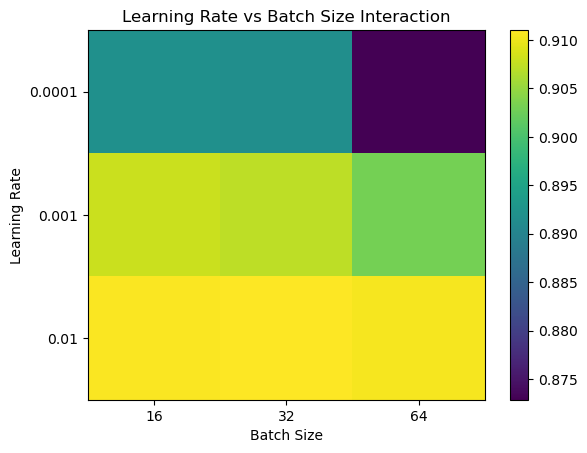

In [65]:
plot_heatmap(df1)


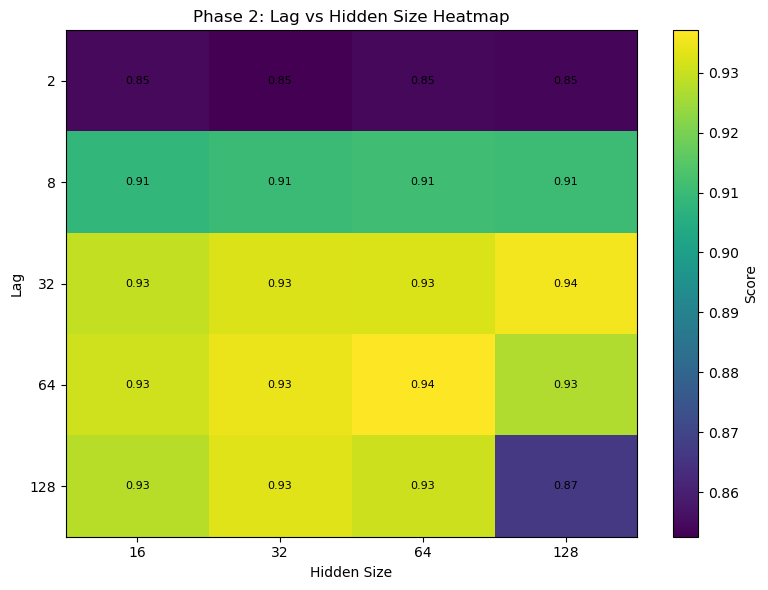

In [63]:
from sympy import plot
plot_phase2_heatmap(df2)


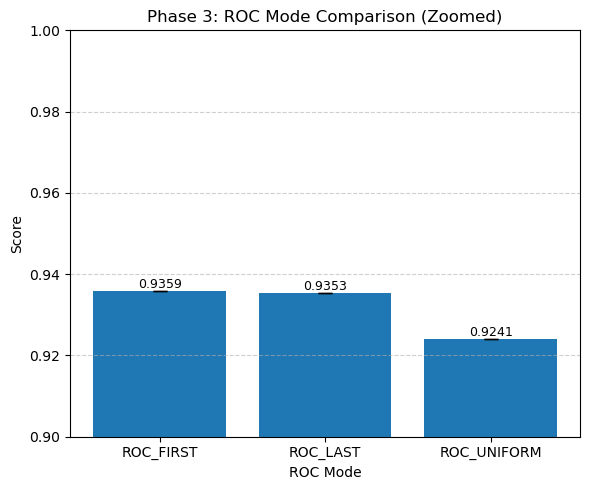

In [69]:
plot_phase3_barchart_zoom(df3)

# Testing

In [70]:
final_model = train_autoregressive(
    name="FINAL_MODEL",
    loader=DataLoader(
        IPDDataset(train_df, seq_len=phase3_config["lag"]),
        batch_size=phase3_config["batch_size"],
        shuffle=True,
        num_workers=4
    ),
    mode=phase3_config["mode"],
    hidden_size=phase3_config["hidden_size"],
    lr=phase3_config["lr"],
    epochs=EPOCH
)

Training FINAL_MODEL on device: cpu
[FINAL_MODEL] Epoch 0: Loss = 4.6154
[FINAL_MODEL] Epoch 1: Loss = 3.8811
[FINAL_MODEL] Epoch 2: Loss = 3.7682
[FINAL_MODEL] Epoch 3: Loss = 3.7121
[FINAL_MODEL] Epoch 4: Loss = 3.6729
[FINAL_MODEL] Epoch 5: Loss = 3.6690
[FINAL_MODEL] Epoch 6: Loss = 3.6385
[FINAL_MODEL] Epoch 7: Loss = 3.6092
[FINAL_MODEL] Epoch 8: Loss = 3.5886
[FINAL_MODEL] Epoch 9: Loss = 3.5760
[FINAL_MODEL] Epoch 10: Loss = 3.5648
[FINAL_MODEL] Epoch 11: Loss = 3.5559
[FINAL_MODEL] Epoch 12: Loss = 3.5415
[FINAL_MODEL] Epoch 13: Loss = 3.5391
[FINAL_MODEL] Epoch 14: Loss = 3.5303
[FINAL_MODEL] Epoch 15: Loss = 3.5324
[FINAL_MODEL] Epoch 16: Loss = 3.5366
[FINAL_MODEL] Epoch 17: Loss = 3.5168
[FINAL_MODEL] Epoch 18: Loss = 3.5232
[FINAL_MODEL] Epoch 19: Loss = 3.5299


In [75]:
dataset_test = IPDDataset(test_df, seq_len=64)
test_loader = DataLoader(
    dataset_test,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

cmA,cmB = evaluate_confusion(final_model, test_loader, device, "Test")
test_metrics = evaluate_metrics_from_confusion(cmA, cmB)
print_metrics("FINAL MODEL TEST RESULTS", test_metrics)



=== Test Confusion Matrix ===

[A]
{'TP': 101616, 'TN': 130193, 'FP': 7121, 'FN': 9902}

[B]
{'TP': 99568, 'TN': 132502, 'FP': 8262, 'FN': 8500}

=== FINAL MODEL TEST RESULTS ===

[A]
accuracy    : 0.9316
precision   : 0.9345
recall      : 0.9112
f1          : 0.9227
specificity : 0.9481

[B]
accuracy    : 0.9326
precision   : 0.9234
recall      : 0.9213
f1          : 0.9224
specificity : 0.9413

[AVG]
accuracy    : 0.9321
precision   : 0.9289
recall      : 0.9163
f1          : 0.9225
specificity : 0.9447


In [76]:
import torch

LAG = 5
PAD = (2, 2)   # IMPORTANT: distinguish from real actions

raw_history = [
    (0, 1),
    (1, 0),
    (0, 1),
    (1, 0),
]

# --- convert to list of tuples ---
tokens = [(a, b) for (a, b) in raw_history]

# --- pad ---
if len(tokens) < LAG:
    tokens = [PAD] * (LAG - len(tokens)) + tokens

# --- convert to tensor (T, 2) ---
history = torch.tensor(tokens, dtype=torch.float)  # float for model

print("Initial history:", history)
print("Shape:", history.shape)  # should be (LAG, 2)

logits = final_model(history.unsqueeze(0).to(device))  # (1, T, 2, 2)
logits_A = logits[:, :, 0, :].argmax(dim=-1).squeeze(0)
logits_B = logits[:, :, 1, :].argmax(dim=-1).squeeze(0)

Initial history: tensor([[2., 2.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.]])
Shape: torch.Size([5, 2])


# Analysis